# Chapter 1. Getting Started with Model Predictive Control
## 모델 예측 제어 시작하기

Rawlings, Mayne, Diehl, *Model Predictive Control: Theory, Computation, and Design*,
2nd edition, 1st printing (2017), Chapter 1, **교재 pp.1–88**를 바탕으로 만든 한글 학습·실습 자료입니다.
페이지는 교재의 인쇄 페이지이며 PDF 파일 페이지와 다릅니다.

**학습 목표**
- 연속시간 모델을 이산시간 상태공간 모델로 변환한다.
- 유한 구간 LQ 문제를 Riccati 재귀와 QP로 풀고 비교한다.
- 최적성과 안정성을 구분하고 제어가능성·관측가능성을 확인한다.
- Kalman Filter, 최소제곱 추정, MHE의 관계를 계산으로 확인한다.
- 정상상태 목표 계산과 외란 추정으로 추종 오차를 제거한다.

**선수 지식:** 행렬 곱·고유값·미분, 평균·공분산, Python/NumPy 기초.

[PPT 원본](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter01_getting_started/slides/chapter01_slides.pptx)
· [PDF 강의자료](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter01_getting_started/slides/chapter01_slides.pdf)

**실행:** Colab에서 `런타임 → 모두 실행`. 개별 실습은 아래 환경 준비 셀을 실행한 뒤 해당 실습의 코드 셀을 실행합니다.
모든 실습은 CPU용이며 로컬 파일이나 저장소 복제가 필요하지 않습니다. 그림은 화면에 표시되고 현재 작업 폴더의 `figures/`에도 저장됩니다.

**구성:** 교재의 모든 1.1–1.6 절과 하위 절 순서를 유지합니다. 이론은 한국어로 재서술하고, 증명은 핵심 아이디어를 설명합니다.
`보충 실습`은 직접 설계한 교육용 예제입니다. 교재의 모든 예제·연습문제에 대한 재현 또는 해답집은 아닙니다.

**목차**
- 1.1 Introduction
- 1.2 Models and Modeling
- 1.3 Introductory MPC Regulator
- 1.4 Introductory State Estimation
- 1.5 Tracking, Disturbances, and Zero Offset
- 1.6 Exercises

**품질 보강판:** 초기조건과 전달함수, 분포 모델의 격자 오차, 제약 설계, 이차 변수 제거, 재계획, 도달·관측 기하, Gaussian 공분산, 평활화와 MHE 도착 비용, 목표 제약, 원본 반응기 외란 모델을 추가했습니다. 모든 예제는 자체 수치 검사를 포함합니다. 해석해·독립 최적화·계수 검사 등 확인 방식이 무엇인지 코드에 명시합니다.


## 실습 환경 준비

이 항목은 교재 외 실행 준비입니다. 필요한 라이브러리가 없을 때만 설치합니다.
행렬 계산은 NumPy, 선형대수·이산화는 SciPy, QP는 CVXPY/OSQP를 사용합니다.
아래 버전 범위는 개발·실행 검증 환경의 주요 버전에 맞췄습니다.
한글 그래프를 위해 Google Fonts의 나눔고딕을 임시 폴더에 내려받습니다. 최초 실행에는 인터넷 연결이 필요합니다.

In [1]:
import importlib.util, subprocess, sys

packages = {
    "numpy": "numpy>=2,<3",
    "scipy": "scipy>=1.14,<2",
    "matplotlib": "matplotlib>=3.9,<4",
    "cvxpy": "cvxpy>=1.6,<2",
    "osqp": "osqp>=1,<2",
}
missing = [
    spec for name, spec in packages.items() if importlib.util.find_spec(name) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import numpy as np
import scipy
from scipy.linalg import solve_discrete_are, expm, solve_triangular
from scipy.signal import cont2discrete
import matplotlib
import matplotlib.pyplot as plt
import cvxpy as cp
from pathlib import Path
import tempfile
import urllib.request
from matplotlib import font_manager

# Colab과 로컬에서 동일하게 한글 그래프를 표시하기 위한 공개 글꼴.
font_dir = Path(tempfile.gettempdir()) / "mpc_korean_fonts"
font_dir.mkdir(exist_ok=True)
font_path = font_dir / "NanumGothic-Regular.ttf"
if not font_path.exists():
    url = "https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
    with urllib.request.urlopen(url, timeout=60) as response:
        font_path.write_bytes(response.read())
font_manager.fontManager.addfont(str(font_path))
korean_font = font_manager.FontProperties(fname=font_path).get_name()

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "axes.grid": True,
        "grid.alpha": 0.22,
        "font.size": 11,
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": ["DejaVu Sans", korean_font],
        "mathtext.fontset": "dejavusans",
        "axes.unicode_minus": False,
    }
)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
CHECKS = {}


def finish_figure(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()


def riccati(A, B, Q, R, Pf, N):
    if not isinstance(N, (int, np.integer)) or N < 1:
        raise ValueError("예측 길이 N은 양의 정수여야 합니다.")
    if not np.allclose(R, R.T) or np.linalg.eigvalsh(R).min() <= 0:
        raise ValueError("입력 비용 R은 대칭 양의 정부호여야 합니다.")
    # 부호 관례: u = K x. K에 음의 부호를 포함한다.
    Ps = [None] * (N + 1)
    Ks = [None] * N
    Ps[N] = Pf.copy()
    for k in range(N - 1, -1, -1):
        Pnext = Ps[k + 1]
        Ks[k] = -np.linalg.solve(R + B.T @ Pnext @ B, B.T @ Pnext @ A)
        Ps[k] = Q + A.T @ Pnext @ A + A.T @ Pnext @ B @ Ks[k]
        Ps[k] = (Ps[k] + Ps[k].T) / 2
    return Ps, Ks


def simulate_linear(A, B, policy, x0, steps):
    xs = [np.array(x0, dtype=float)]
    us = []
    for k in range(steps):
        u = np.atleast_1d(policy(xs[-1], k))
        if u.shape != (B.shape[1],) or not np.all(np.isfinite(u)):
            raise ValueError("정책은 유한한 입력 벡터를 반환해야 합니다.")
        us.append(u)
        xs.append(A @ xs[-1] + B @ u)
    return np.array(xs), np.array(us)


def checked_solve(problem):
    problem.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8, max_iter=20000)
    if problem.status != cp.OPTIMAL or not np.isfinite(problem.value):
        raise RuntimeError(f"최적화 실패: {problem.status}")
    # 솔버 상태 외에 실제 등식/부등식 잔차도 검사한다.
    residual = max((float(np.max(c.violation())) for c in problem.constraints), default=0.0)
    if residual > 1e-5:
        raise RuntimeError(f"최적화 제약 위반: {residual:.2e}")
    return {"objective": float(problem.value), "constraint_residual": residual}


def kalman(A, B, C, W, V, y, u, mean0, cov0):
    # y[k]는 x[k]의 관측. 측정 갱신 후 u[k]로 다음 시점을 예측한다.
    if len(y) < 1 or len(u) < len(y) - 1:
        raise ValueError("측정 T개에는 전이 입력 T-1개 이상이 필요합니다.")
    mean, cov = mean0.copy(), cov0.copy()
    prior_m, prior_P, post_m, post_P = [], [], [], []
    for k in range(len(y)):
        prior_m.append(mean.copy())
        prior_P.append(cov.copy())
        L = np.linalg.solve(C @ cov @ C.T + V, C @ cov).T
        mean = mean + L @ (y[k] - C @ mean)
        ILC = np.eye(len(mean)) - L @ C
        cov = ILC @ cov @ ILC.T + L @ V @ L.T  # Joseph form
        cov = (cov + cov.T) / 2
        post_m.append(mean.copy())
        post_P.append(cov.copy())
        if k + 1 < len(y):
            mean = A @ mean + B @ u[k]
            cov = A @ cov @ A.T + W
            cov = (cov + cov.T) / 2
    return tuple(np.array(v) for v in (prior_m, prior_P, post_m, post_P))


def estimation_data():
    # 모든 추정 실습이 같은 데이터 생성 함수를 사용한다.
    A = np.array([[1.0, 0.2], [0.0, 0.95]])
    B = np.array([[0.02], [0.2]])
    C = np.array([[1.0, 0.0]])
    W = np.diag([0.002, 0.004])
    V = np.array([[0.16]])
    rng = np.random.default_rng(42)
    u = (0.3 * np.sin(np.arange(80) * 0.12))[:, None]
    x = np.zeros((81, 2))
    x[0] = [1.5, -0.5]
    y = np.zeros((80, 1))
    for k in range(80):
        y[k] = C @ x[k] + rng.multivariate_normal(np.zeros(1), V)
        x[k + 1] = A @ x[k] + B @ u[k] + rng.multivariate_normal(np.zeros(2), W)
    return A, B, C, W, V, x, y, u


print(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "SciPy": scipy.__version__,
        "Matplotlib": matplotlib.__version__,
        "CVXPY": cp.__version__,
    }
)
print(
    "환경 준비 완료. 각 실습은 공통 함수만 사용하며 앞 실습의 결과에는 의존하지 않습니다."
)


def linear_window_ls(A, B, C, W, V, y, u, prior=None):
    """무제약 선형 Gaussian 최소제곱. prior=(평균, 공분산), None이면 도착 비용 0.

    y는 (T,p), u는 (T-1,m). 반환: (T,n) 상태와 정규방정식 잔차.
    공분산 S=L Lᵀ에 대해 L^{-1}r를 삼각계 풀이로 계산한다.
    역행렬과 정규방정식의 직접 풀이를 피하고 SVD 기반 lstsq를 사용한다.
    """
    y, u = np.asarray(y), np.asarray(u)
    T, n, p = len(y), A.shape[0], C.shape[0]
    if T < 1 or y.shape != (T, p) or u.shape != (T - 1, B.shape[1]):
        raise ValueError("y: (T,p), u: (T-1,m) 형식을 확인하세요.")
    rows, rhs = [], []

    def append(block, value, covariance):
        L = np.linalg.cholesky(covariance)
        rows.append(solve_triangular(L, block, lower=True))
        rhs.append(solve_triangular(L, value, lower=True))

    if prior is not None:
        m0, P0 = prior
        block = np.zeros((n, T * n))
        block[:, :n] = np.eye(n)
        append(block, m0, P0)
    for j in range(T):
        block = np.zeros((p, T * n))
        block[:, j * n : (j + 1) * n] = C
        append(block, y[j], V)
        if j < T - 1:
            block = np.zeros((n, T * n))
            block[:, j * n : (j + 1) * n] = -A
            block[:, (j + 1) * n : (j + 2) * n] = np.eye(n)
            append(block, B @ u[j], W)
    M, b = np.vstack(rows), np.concatenate(rhs)
    z, _, rank, _ = np.linalg.lstsq(M, b, rcond=None)
    if rank != T * n:
        raise ValueError(
            "추정이 유일하지 않습니다. prior 또는 충분한 관측 구간이 필요합니다."
        )
    optimality = np.linalg.norm(M.T @ (M @ z - b), ord=np.inf)
    if optimality > 1e-7 * (1 + np.linalg.norm(M.T @ b, ord=np.inf)):
        raise RuntimeError("최소제곱 최적성 잔차가 큽니다.")
    return z.reshape(T, n), float(optimality)


{'Python': '3.11.15', 'NumPy': '2.4.6', 'SciPy': '1.17.1', 'Matplotlib': '3.11.1', 'CVXPY': '1.9.2'}
환경 준비 완료. 각 실습은 공통 함수만 사용하며 앞 실습의 결과에는 의존하지 않습니다.


## 1.1 Introduction — 개요

**교재 p.1**

MPC는 모델로 미래를 예측하고, 목적함수가 가장 작아지는 입력 열을 계산합니다. 그중 첫 입력만 실제 시스템에 적용한 뒤, 새 측정값으로 상태를 추정하고 다시 계산합니다.

이 장은 모델, 조절기, 상태 추정기, 정상상태 목표 계산기를 하나의 제어 구조로 연결합니다. 추정은 과거 측정을 정리하는 문제이고, 제어는 앞으로의 행동을 정하는 문제입니다.

## 1.2 Models and Modeling — 모델과 모델링

**교재 p.1–10**

상태 $x$는 미래 거동을 예측하는 데 필요한 내부 변수, 입력 $u$는 조작 가능한 변수, 출력 $y$는 측정하는 변수입니다. 모델의 정확도뿐 아니라 계산 비용과 사용할 수 있는 측정 정보도 함께 고려합니다.

아래에서는 연속시간 모델과 이산시간 모델을 구분합니다. 코드의 배열 한 행은 한 시점의 상태를 나타냅니다.

$$
\dot{x}=f(x,u,t),\qquad y=h(x,u,t)
$$

### 1.2.1 Linear Dynamic Models — 선형 동적 모델

**교재 p.2–3**

선형 시불변 모델에서는 행렬 $A_c,B_c,C,D$가 일정합니다. 비선형 공정을 운전점 근처에서 선형화했다면 상태와 입력은 그 운전점에 대한 편차입니다. 선형 근사가 유효한 범위를 벗어나면 예측 오차가 커질 수 있습니다.

$$
\dot{x}=A_cx+B_cu,\qquad y=Cx+Du
$$

교재는 먼저 $A_c(t),B_c(t)$가 시간에 따라 바뀌는 선형 시변 모델을 제시하고 시불변 모델로 좁힙니다. 시불변일 때 해는 **초기상태 응답 + 입력 응답**입니다.
$$x(t)=e^{A_ct}x(0)+\int_0^t e^{A_c(t-\tau)}B_cu(\tau)\,d\tau.$$
이 두 항을 구분하면 전달함수에서 초기조건이 왜 별도로 필요한지 이해할 수 있습니다.


### 1.2.2 Input-Output Models — 입출력 모델

**교재 p.3–4**

전달함수는 입력과 출력의 관계를 표현합니다. 상태공간 표현에서 전달함수로 옮길 때 아래 식은 초기상태가 0이라는 조건을 사용합니다. 초기상태가 0이 아니면 초기조건 응답도 더해야 합니다.

$$
G(s)=C(sI-A_c)^{-1}B_c+D
$$

**보충 실습 — 전달함수에 들어 있지 않은 초기조건 (교재 pp.2–4 연결)**

$\dot x=-x+u$, $u=1$, $x(0)=2$에서 초기조건 응답은 $2e^{-t}$, 영초기조건 계단 응답은 $1-e^{-t}$입니다. 두 응답의 합을 상태공간 이산화 결과와 비교합니다. 전달함수의 계단 응답만 사용하면 시작점을 잘못 예측합니다.

**바꿔 보기:** `x0=0`이면 두 곡선이 왜 같아질까요? 음의 초기상태도 시험하세요.

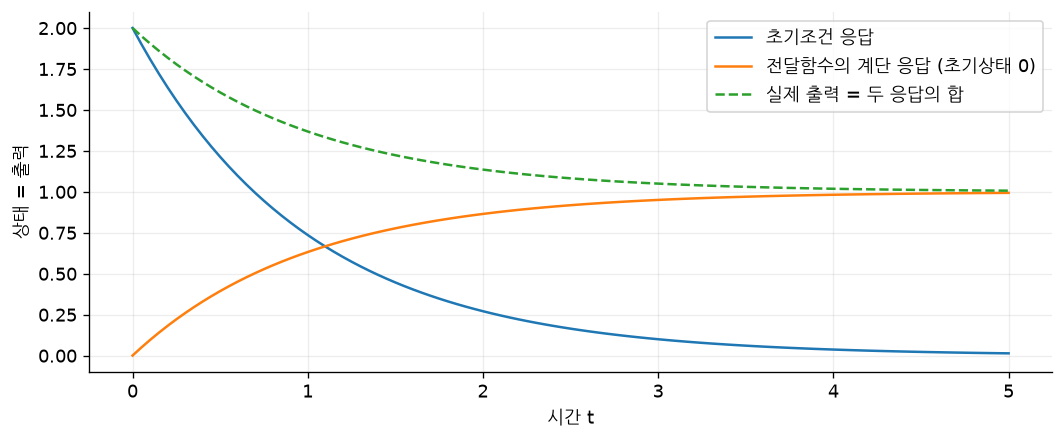

In [2]:
def demo_initial_response(x0=2.0):
    dt = 0.05
    t = np.arange(101) * dt
    a = np.exp(-dt)
    b = 1 - a
    xs, _ = simulate_linear(np.array([[a]]), np.array([[b]]), lambda x, k: [1.0], [x0], 100)
    natural = x0 * np.exp(-t)
    forced = 1 - np.exp(-t)
    err = np.max(np.abs(xs[:, 0] - natural - forced))
    assert err < 1e-12
    CHECKS["initial plus forced response error"] = float(err)
    plt.figure(figsize=(9, 3.8))
    plt.plot(t, natural, label="초기조건 응답")
    plt.plot(t, forced, label="전달함수의 계단 응답 (초기상태 0)")
    plt.plot(t, xs[:, 0], "--", label="실제 출력 = 두 응답의 합")
    plt.xlabel("시간 t")
    plt.ylabel("상태 = 출력")
    plt.legend()
    finish_figure("initial_response")
    return {"time": t, "state": xs[:, 0], "error": err}


initial_result = demo_initial_response()


### 1.2.3 Distributed Models — 분포 모델

**교재 p.4**

온도나 농도가 위치에 따라 달라지는 시스템은 시간뿐 아니라 공간에 대한 편미분방정식으로 표현할 수 있습니다. 공간을 여러 구간으로 나누면 각 구간의 값이 상태가 되어 큰 상태공간 모델을 얻습니다.

여기서 distributed는 분포정수 모델을 뜻합니다. 6장의 여러 제어기가 협력하는 분산 제어와는 구분해야 합니다.

분포의 독립변수는 공간만이 아닙니다. 원본은 **잘 혼합된 반응기에서도 입자 크기 $r$에 대한 분포 $f(r,t)$**가 필요할 수 있음을 설명합니다. 아래 열 확산 모델은 공간 이산화를 보여 주기 위한 자체 예제이며, 교재의 입자 성장 모델을 재현한 것은 아닙니다.


**보충 실습 — 편미분방정식에서 상태 벡터로**

길이 1 막대의 $T_t=\alpha T_{zz}$, 양 끝 온도 0, 초기 온도 $\sin(\pi z)$를 사용합니다. 내부 격자 온도 $n$개를 상태로 두면 $\dot x=A_cx$이고 $A_c$는 삼중대각 행렬입니다. 해석해 $T(z,t)=e^{-\alpha\pi^2t}\sin(\pi z)$와 비교합니다. 시간 전파는 행렬 지수로 정확히 계산하므로 아래 오차는 공간 이산화에서 옵니다.

**읽는 법:** 왼쪽은 온도 분포의 시간 변화, 오른쪽은 격자를 두 배 촘촘히 했을 때 오차가 약 1/4로 줄어드는 2차 공간 근사입니다. 높은 정확도에는 더 많은 상태와 계산이 필요합니다.

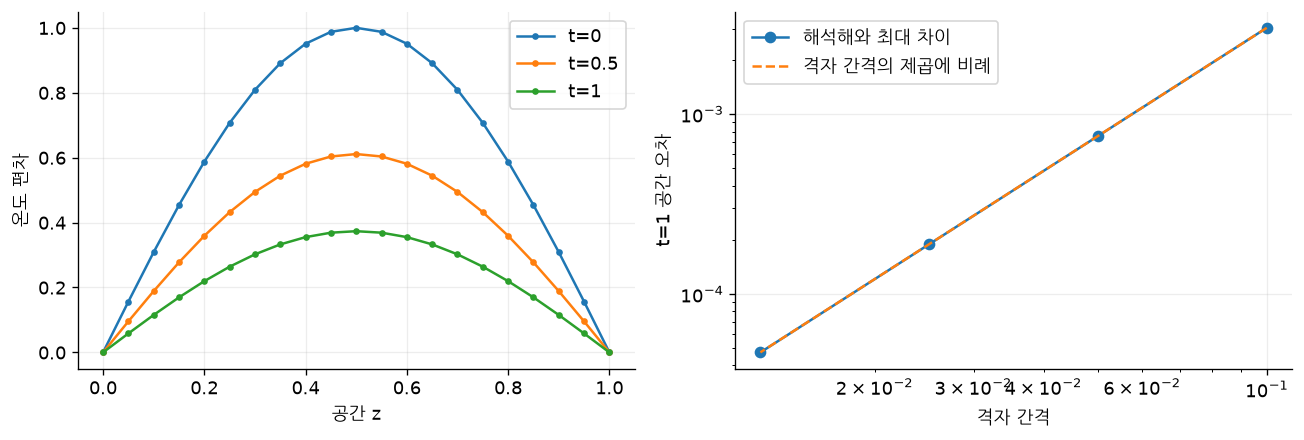

In [3]:
def demo_distributed_model(alpha=0.1):
    if alpha <= 0:
        raise ValueError("열 확산 계수는 양수여야 합니다.")
    grids = [9, 19, 39, 79]
    errors = []
    spacings = []
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for n in grids:
        h = 1 / (n + 1)
        z = np.arange(1, n + 1) * h
        Ac = (
            alpha
            / h**2
            * (
                np.diag(-2 * np.ones(n))
                + np.diag(np.ones(n - 1), 1)
                + np.diag(np.ones(n - 1), -1)
            )
        )
        x0 = np.sin(np.pi * z)
        approx = expm(Ac) @ x0
        exact = np.exp(-alpha * np.pi**2) * x0
        errors.append(np.max(np.abs(approx - exact)))
        spacings.append(h)
        if n == 19:
            for t in [0, 0.5, 1.0]:
                axes[0].plot(
                    np.r_[0, z, 1],
                    np.r_[0, expm(Ac * t) @ x0, 0],
                    "o-",
                    ms=3,
                    label=f"t={t:g}",
                )
    ratios = np.array(errors[:-1]) / errors[1:]
    assert np.all((ratios > 3.8) & (ratios < 4.2))
    CHECKS["PDE spatial error ratio min"] = float(ratios.min())
    axes[0].set(xlabel="공간 z", ylabel="온도 편차")
    axes[0].legend()
    axes[1].loglog(spacings, errors, "o-", label="해석해와 최대 차이")
    axes[1].loglog(
        spacings,
        errors[0] * (np.array(spacings) / spacings[0]) ** 2,
        "--",
        label="격자 간격의 제곱에 비례",
    )
    axes[1].set(xlabel="격자 간격", ylabel="t=1 공간 오차")
    axes[1].legend()
    finish_figure("distributed_model")
    return {"errors": np.array(errors), "ratios": ratios}


distributed_result = demo_distributed_model()


### 1.2.4 Discrete Time Models — 이산시간 모델

**교재 p.5–6**

샘플링 간격 $\Delta$ 동안 입력을 일정하게 유지하는 ZOH를 가정하면 연속시간 선형 모델을 정확히 이산화할 수 있습니다. $A_c$가 특이행렬이어도 적분 또는 블록 행렬 지수로 $B$를 계산할 수 있으므로 역행렬 공식에 의존할 필요가 없습니다.

$$
x^+=Ax+Bu,\quad A=e^{A_c\Delta},\quad B=\int_0^\Delta e^{A_c\tau}B_c\,d\tau
$$

**보충 실습 — 이중 적분기의 ZOH 이산화**

상태는 위치와 속도, 입력은 가속도입니다. 동일한 연속시간 입력에서 정확한 ZOH와 전진 Euler를 비교합니다.
Euler는 입력이 위치에 미치는 구간 내 효과를 놓치므로 위치 오차가 누적됩니다.

A =
[[1.  0.4]
 [0.  1. ]]
B =
[[0.08]
 [0.4 ]]


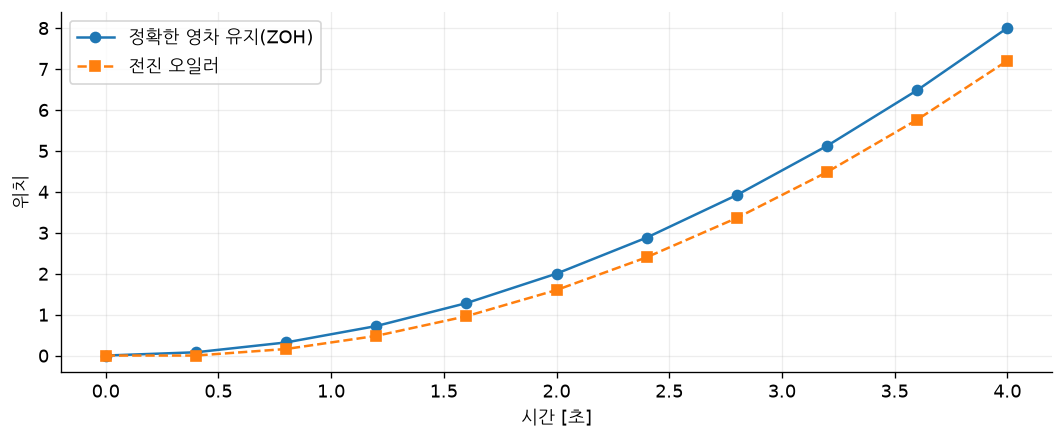

In [4]:
def demo_discretization(dt=0.4):
    Ac = np.array([[0.0, 1.0], [0.0, 0.0]])
    Bc = np.array([[0.0], [1.0]])
    C = np.array([[1.0, 0.0]])
    A, B, _, _, _ = cont2discrete((Ac, Bc, C, np.zeros((1, 1))), dt)
    Ae, Be = np.eye(2) + dt * Ac, dt * Bc
    xs, _ = simulate_linear(A, B, lambda x, k: [1.0], [0.0, 0.0], 10)
    xe, _ = simulate_linear(Ae, Be, lambda x, k: [1.0], [0.0, 0.0], 10)
    t = np.arange(11) * dt
    assert np.allclose(xs[:, 0], 0.5 * t * t)
    CHECKS["ZOH analytical match"] = float(np.max(np.abs(xs[:, 0] - 0.5 * t * t)))
    print("A =", A, "B =", B, sep="\n")
    plt.figure()
    plt.plot(t, xs[:, 0], "o-", label="정확한 영차 유지(ZOH)")
    plt.plot(t, xe[:, 0], "s--", label="전진 오일러")
    plt.xlabel("시간 [초]")
    plt.ylabel("위치")
    plt.legend()
    finish_figure("model_discretization")


demo_discretization()


### 1.2.5 Constraints — 제약조건

**교재 p.6–9**

입력에는 토크·전압·유량의 한계가 있고 상태나 출력에도 운전 범위가 있습니다. 제약은 최적화 문제 안에서 미래 예측에 적용해야 합니다. 제약 없이 설계한 입력을 나중에 잘라내면 원래 최적해와 달라지고 안정성·성능 보장도 그대로 유지되지 않습니다.

$$
Eu\leq e,\qquad Fy\leq f
$$

**입력 변화율과 연성 제약 (교재 pp.6–9)**

밸브를 한 번에 크게 움직이지 않으려면 $|u_k-u_{k-1}|\le\Delta u_{\max}$를 넣습니다. 이전 입력을 상태에 포함하면 $\xi_k=[x_k^T,u_{k-1}^T]^T$인 확장 모델로도 표현할 수 있습니다. 입력의 물리적 한계는 경성 제약으로 두되, 상태 운전 범위는 필요에 따라 여유변수 $\epsilon\ge0$와 벌점으로 완화할 수 있습니다. 이산 액추에이터 $u\in\{0,1\}$는 별도의 정수 최적화가 필요합니다.

**보충 실습:** $x^+=0.9x+0.2u$, $x_0=1.5$, $|u|\le1$, $|x_1|\le0.5$이면 최대 제동을 해도 $x_1\ge1.15$라 경성 문제는 불가능합니다. 상태만 완화하면 해가 존재하지만, 입력 한계는 계속 지킵니다. 변화율 제약까지 넣으면 첫 입력은 -0.2 이상이라 위반량이 더 커집니다. 연성 제약은 물리적 안전을 보장하는 장치가 아닙니다.

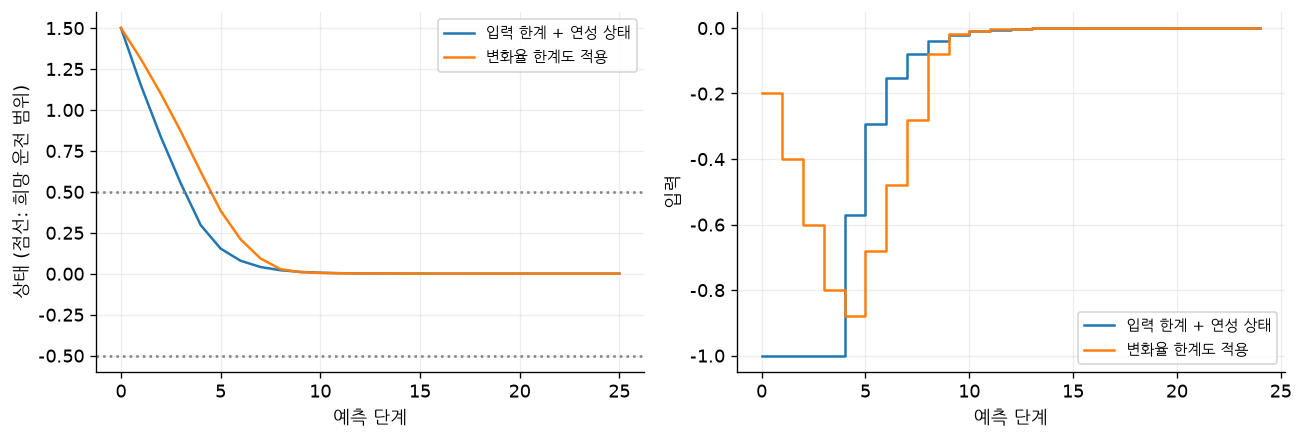

In [5]:
def demo_constraint_design(move_limit=0.2):
    if move_limit <= 0:
        raise ValueError("입력 변화 한계는 양수여야 합니다.")
    N = 25
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    results = {}
    assert 0.9 * 1.5 - 0.2 > 0.5  # 첫 전이의 도달 가능 하한: 경성 문제 불가능
    for label, rate in [
        ("입력 한계 + 연성 상태", None),
        ("변화율 한계도 적용", move_limit),
    ]:
        x = cp.Variable(N + 1)
        u = cp.Variable(N)
        slack = cp.Variable(N, nonneg=True)
        cons = [
            x[0] == 1.5,
            x[1:] == 0.9 * x[:-1] + 0.2 * u,
            cp.abs(u) <= 1,
            cp.abs(x[1:]) <= 0.5 + slack,
        ]
        if rate is not None:
            cons += [cp.abs(u - cp.hstack([0, u[:-1]])) <= rate]
        prob = cp.Problem(
            cp.Minimize(
                0.5 * (cp.sum_squares(x) + 0.1 * cp.sum_squares(u))
                + 100 * cp.sum_squares(slack)
            ),
            cons,
        )
        info = checked_solve(prob)
        assert np.max(np.abs(u.value)) <= 1 + 1e-6
        assert np.max(np.abs(np.maximum(np.abs(x.value[1:]) - 0.5, 0) - slack.value)) < 1e-5
        if rate is not None:
            assert np.max(np.abs(np.diff(np.r_[0, u.value]))) <= rate + 1e-6
        axes[0].plot(x.value, label=label)
        axes[1].step(np.arange(N), u.value, where="post", label=label)
        results[label] = {
            "state": x.value.copy(),
            "input": u.value.copy(),
            "slack": slack.value.copy(),
            **info,
        }
    for y in [-0.5, 0.5]:
        axes[0].axhline(y, color="gray", ls=":")
    axes[0].set(xlabel="예측 단계", ylabel="상태 (점선: 희망 운전 범위)")
    axes[1].set(xlabel="예측 단계", ylabel="입력")
    for ax in axes:
        ax.legend(fontsize=9)
    CHECKS["soft constraint max residual"] = max(
        v["constraint_residual"] for v in results.values()
    )
    finish_figure("constraint_design")
    return results


constraint_result = demo_constraint_design()


### 1.2.6 Deterministic and Stochastic — 결정론적 모델과 확률적 모델

**교재 p.9–10**

결정론적 모델은 초기상태와 입력이 주어지면 하나의 궤적을 냅니다. 확률적 모델은 과정 잡음 $w$와 측정 잡음 $v$를 포함하여 가능한 궤적의 분포를 다룹니다. 이 노트북의 추정 실습에서는 서로 독립인 영평균 Gaussian 잡음을 사용합니다.

$$
x^+=Ax+Bu+w,\quad y=Cx+v,\quad w\sim\mathcal{N}(0,W),\ v\sim\mathcal{N}(0,V)
$$

## 1.3 Introductory MPC Regulator — MPC 조절기 입문

**교재 p.11–25**

조절 문제는 상태를 원점으로 보내는 입력을 찾습니다. 먼저 제약 없는 선형·이차 문제에서 해의 구조를 이해하고, 제약이 있을 때 QP가 어떻게 달라지는지 실습합니다.

유한 시간 문제에서 얻은 시간별 입력을 끝까지 적용하는 것과, 매 시점 같은 예측 길이로 다시 푸는 receding horizon 제어를 구분합니다.

### 1.3.1 Linear Quadratic Problem — 선형 이차 최적 제어

**교재 p.11–12**

$Q\succeq0$는 상태 편차, $R\succ0$는 입력 사용량, $P_f\succeq0$는 마지막 상태를 평가합니다. 모든 비용에 공통으로 곱하는 $1/2$는 최적 입력을 바꾸지 않습니다. 교재와 동일하게 여기서는 $1/2$를 사용합니다.

$$
J=\frac12 x_N^TP_fx_N+\frac12\sum_{k=0}^{N-1}(x_k^TQx_k+u_k^TRu_k)
$$

### 1.3.2 Optimizing Multistage Functions — 다단계 함수 최적화

**교재 p.12–18**

모든 입력을 한꺼번에 최적화할 수도 있고, 마지막 단계의 최적 비용을 먼저 구한 뒤 앞 단계로 넘어갈 수도 있습니다. 뒤쪽 변수의 최적화 결과를 값 함수로 요약하면 각 단계에서 같은 형태의 작은 문제를 풀 수 있습니다.

$$
\min_{u_0,u_1}J=\min_{u_0}\left[\min_{u_1}J\right]
$$

**왜 작은 최적화 문제를 이어 붙일 수 있을까?**

인접 변수끼리만 결합한 $f(w,x)+g(x,y)+h(y,z)$에서 뒤쪽 $z$를 최소화한 결과는 $y$의 함수입니다. 그 값 함수로 $z$를 없앤 후 $y$를 제거합니다. 제어에서는 초기상태를 매개변수로 고정하고 뒤에서 앞으로, 추정에서는 마지막 상태를 매개변수로 남기고 앞에서 뒤로 정보를 압축합니다. 순서를 바꾸어도 동일한 목적함수를 풀어야 합니다.

**보충 실습 — 완전제곱과 Schur complement**
$$J(x,u)=\tfrac12(ax^2+2bxu+cu^2)=\tfrac12c(u+bx/c)^2+\tfrac12(a-b^2/c)x^2.$$
$c>0$이면 $u^*=-bx/c$, $V(x)=\tfrac12(a-b^2/c)x^2$입니다. 이 한 단계 계산을 반복한 것이 Riccati 재귀입니다. 아래는 자체 계수 $a=4,b=1,c=2$를 사용합니다.

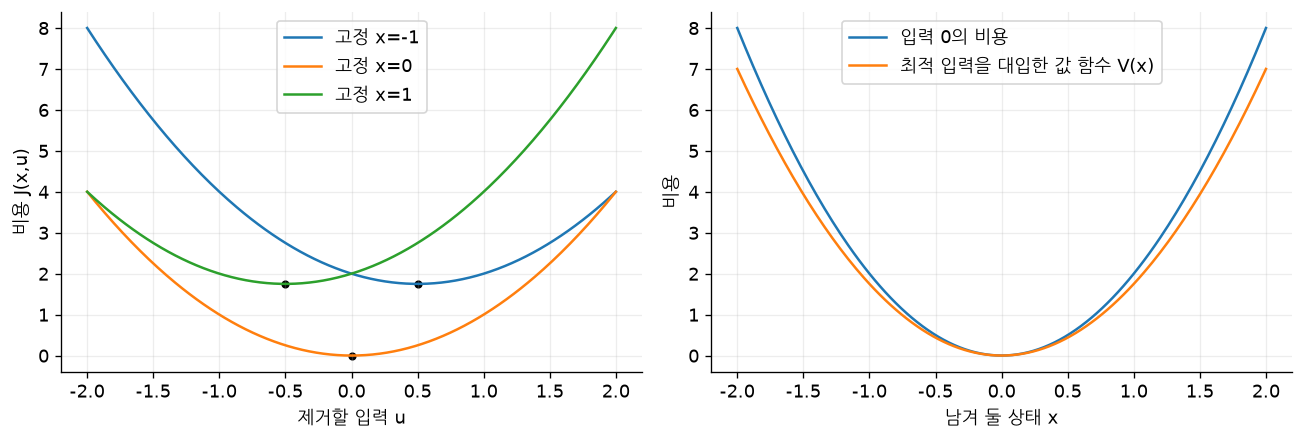

In [6]:
def demo_quadratic_elimination():
    a, b, c = 4.0, 1.0, 2.0
    x = np.linspace(-2, 2, 201)
    ustar = -b * x / c
    value = 0.5 * (a - b * b / c) * x * x
    direct = 0.5 * (a * x * x + 2 * b * x * ustar + c * ustar * ustar)
    assert np.max(np.abs(direct - value)) < 1e-12
    assert np.max(np.abs(b * x + c * ustar)) < 1e-12
    CHECKS["Schur value error"] = float(np.max(np.abs(direct - value)))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    uu = np.linspace(-2, 2, 301)
    for xx in [-1.0, 0.0, 1.0]:
        axes[0].plot(
            uu, 0.5 * (a * xx * xx + 2 * b * xx * uu + c * uu * uu), label=f"고정 x={xx:g}"
        )
        axes[0].scatter(
            [-b * xx / c], [0.5 * (a - b * b / c) * xx * xx], color="black", s=15
        )
    axes[0].set(xlabel="제거할 입력 u", ylabel="비용 J(x,u)")
    axes[0].legend()
    axes[1].plot(x, 0.5 * a * x * x, label="입력 0의 비용")
    axes[1].plot(x, value, label="최적 입력을 대입한 값 함수 V(x)")
    axes[1].set(xlabel="남겨 둘 상태 x", ylabel="비용")
    axes[1].legend()
    finish_figure("quadratic_elimination")


demo_quadratic_elimination()


### 1.3.3 Dynamic Programming Solution — 동적 계획법 해법

**교재 p.18–21**

종단 조건 $P_N=P_f$에서 시작해 시간을 거슬러 계산합니다. $V_k(x)=\frac12x^TP_kx$를 대입하고 입력으로 미분하면 선형 피드백을 얻습니다. 이 자료는 교재처럼 **$u=Kx$이며 $K$에 음의 부호를 포함**합니다.

$$
K_k=-(R+B^TP_{k+1}B)^{-1}B^TP_{k+1}A
$$

Riccati 재귀는 다음과 같습니다.
$$P_k=Q+A^TP_{k+1}A-A^TP_{k+1}B(R+B^TP_{k+1}B)^{-1}B^TP_{k+1}A.$$

**보충 실습 — Riccati 해와 QP 해 비교**

동일한 모델·비용·종단 조건을 두 방식으로 풀어 전체 입력 열과 목적함수를 비교합니다.
첫 번째 그래프는 무한 구간 LQR에서 입력 가중치만 바꾸었을 때의 응답입니다.

DP-QP 입력 최대 차이: 1.69e-15; 최적 비용: 43.444581


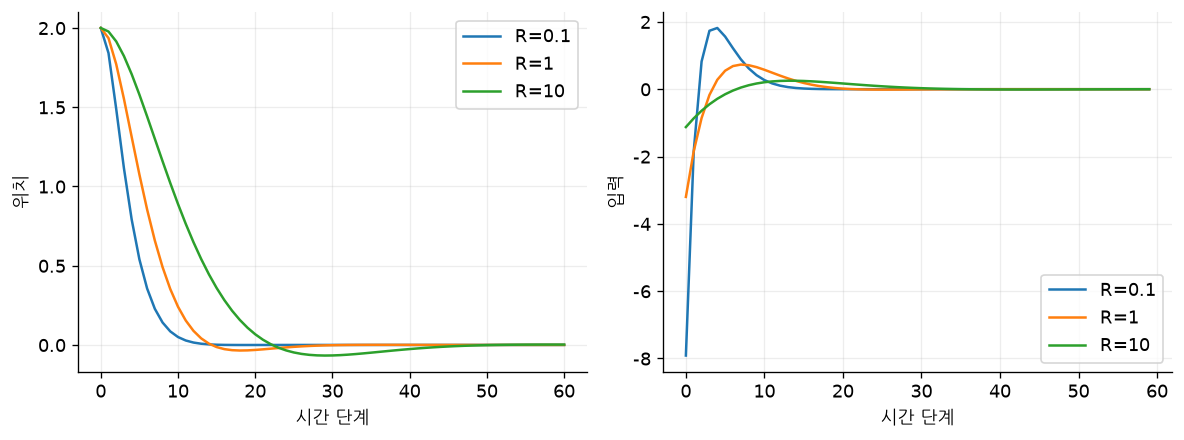

In [7]:
def demo_lqr():
    A = np.array([[1.0, 0.2], [0.0, 1.0]])
    B = np.array([[0.02], [0.2]])
    Q = np.diag([4.0, 1.0])
    R = np.array([[0.5]])
    Pf = Q.copy()
    N = 15
    x0 = np.array([2.0, 0.0])
    Ps, Ks = riccati(A, B, Q, R, Pf, N)
    xd, ud = simulate_linear(A, B, lambda x, k: Ks[k] @ x, x0, N)
    x = cp.Variable((2, N + 1))
    u = cp.Variable((1, N))
    cons = [x[:, 0] == x0]
    cost = 0.5 * cp.quad_form(x[:, N], Pf)
    for k in range(N):
        cost += 0.5 * (cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R))
        cons += [x[:, k + 1] == A @ x[:, k] + B @ u[:, k]]
    prob = cp.Problem(cp.Minimize(cost), cons)
    checked_solve(prob)
    err = np.max(np.abs(ud.T - u.value))
    assert err < 1e-5
    assert abs(prob.value - 0.5 * x0 @ Ps[0] @ x0) < 1e-5
    CHECKS["DP vs QP max input difference"] = float(err)
    print(f"DP-QP 입력 최대 차이: {err:.2e}; 최적 비용: {prob.value:.6f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for rv in [0.1, 1.0, 10.0]:
        Rv = np.array([[rv]])
        P = solve_discrete_are(A, B, Q, Rv)
        K = -np.linalg.solve(Rv + B.T @ P @ B, B.T @ P @ A)
        xs, us = simulate_linear(A, B, lambda x, k: K @ x, x0, 60)
        axes[0].plot(xs[:, 0], label=f"R={rv:g}")
        axes[1].plot(us[:, 0], label=f"R={rv:g}")
    axes[0].set(xlabel="시간 단계", ylabel="위치")
    axes[1].set(xlabel="시간 단계", ylabel="입력")
    for ax in axes:
        ax.legend()
    finish_figure("lqr_weights")


demo_lqr()


**해석:** QP와 Riccati의 입력 차이가 수치 허용오차 안이면 같은 최적화 문제를 풀었다는 뜻입니다.
입력 가중치가 작을수록 초기 제어 입력이 커지는 경향을 확인합니다. 이 LQR에는 입력 제약이 없습니다.

### 1.3.4 The Infinite Horizon LQ Problem — 무한 구간 LQ 문제

**교재 p.21–23**

짧은 예측 구간에서 비용을 최소화했다고 해서 폐루프가 안정한 것은 아닙니다. 교재는 안정한 시스템조차 특정 유한 구간 LQ 피드백으로 불안정해질 수 있음을 보입니다.

무한 구간에서는 Riccati 재귀의 정상해인 DARE 해를 사용합니다. 안정화 가능성 등 필요한 조건 아래 안정화 해를 얻습니다.

$$
P=Q+A^TPA-A^TPB(R+B^TPB)^{-1}B^TPA
$$

**교재 사례 재현 — §1.3.4, pp.21–22의 유한 구간 불안정 사례**

교재의 $A,B,C,Q,R,P_f=Q$를 그대로 사용합니다. 각 $N$에 대해 첫 이득 $K_0$를 매 시점 반복 적용한다고 가정합니다.
스펙트럴 반지름 $\rho(A+BK_0)<1$이 이산시간 선형 폐루프 안정성 기준입니다.

N=5: 1.307, N=7: 0.989, infinite: 0.664


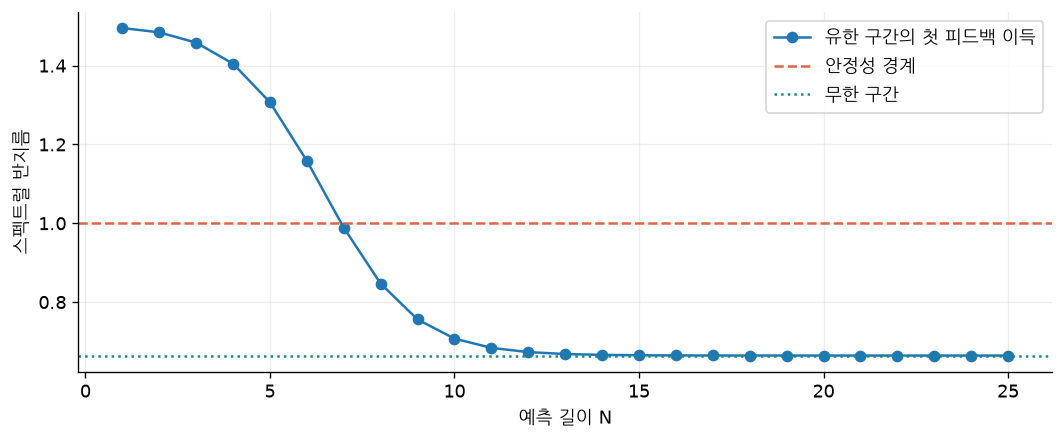

In [8]:
def demo_horizon():
    A = np.array([[4 / 3, -2 / 3], [1.0, 0.0]])
    B = np.array([[1.0], [0.0]])
    C = np.array([[-2 / 3, 1.0]])
    Q = C.T @ C + 0.001 * np.eye(2)
    R = np.array([[0.001]])
    ns = np.arange(1, 26)
    radii = []
    for N in ns:
        _, Ks = riccati(A, B, Q, R, Q, int(N))
        radii.append(np.max(np.abs(np.linalg.eigvals(A + B @ Ks[0]))))
    P = solve_discrete_are(A, B, Q, R)
    K = -np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    rho_inf = np.max(np.abs(np.linalg.eigvals(A + B @ K)))
    assert radii[4] > 1 and radii[6] < 1 and rho_inf < 1
    CHECKS["finite horizon N5 rho"] = float(radii[4])
    CHECKS["finite horizon N7 rho"] = float(radii[6])
    print(f"N=5: {radii[4]:.3f}, N=7: {radii[6]:.3f}, infinite: {rho_inf:.3f}")
    plt.figure()
    plt.plot(ns, radii, "o-", label="유한 구간의 첫 피드백 이득")
    plt.axhline(1, color="#dd6644", ls="--", label="안정성 경계")
    plt.axhline(rho_inf, color="#168b86", ls=":", label="무한 구간")
    plt.xlabel("예측 길이 N")
    plt.ylabel("스펙트럴 반지름")
    plt.legend()
    finish_figure("horizon_stability")


demo_horizon()


### 1.3.5 Controllability — 제어가능성

**교재 p.23–24**

제어가능성은 입력을 통해 임의의 상태 사이를 유한 시간 안에 이동할 수 있는 성질입니다. $n$차 선형 시스템의 제어가능 행렬이 행 계수 $n$이면 제어가능합니다. 안정화 가능성은 더 약한 조건으로, 제어할 수 없는 모드가 모두 안정하면 충분합니다.

$$
\mathcal{C}=[B\ AB\ \cdots\ A^{n-1}B],\quad\operatorname{rank}\mathcal{C}=n
$$

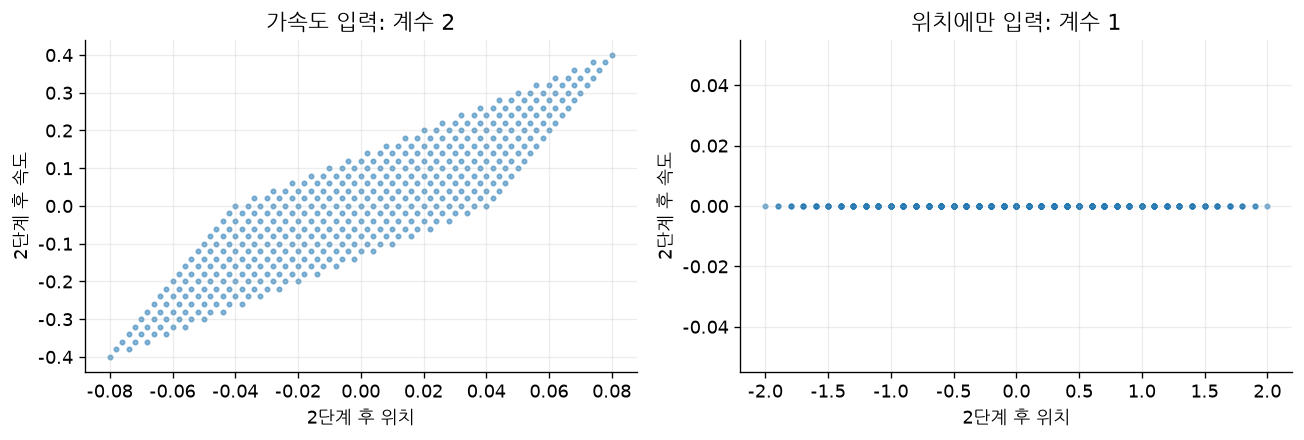

[2, 1]

In [9]:
def demo_controllability():
    A = np.array([[1.0, 0.2], [0.0, 1.0]])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ranks = []
    u0, u1 = np.meshgrid(np.linspace(-1, 1, 21), np.linspace(-1, 1, 21))
    for ax, label, B in zip(
        axes,
        ["가속도 입력", "위치에만 입력"],
        [np.array([[0.02], [0.2]]), np.array([[1.0], [0.0]])],
    ):
        reach = np.hstack([A @ B, B])
        rank = int(np.linalg.matrix_rank(reach))
        ranks.append(rank)
        states = reach @ np.vstack([u0.ravel(), u1.ravel()])
        ax.scatter(states[0], states[1], s=7, alpha=0.5)
        ax.set(
            title=f"{label}: 계수 {rank}", xlabel="2단계 후 위치", ylabel="2단계 후 속도"
        )
    assert ranks == [2, 1]
    CHECKS["controllability ranks"] = ranks
    finish_figure("controllability")
    return ranks


demo_controllability()


**해석:** $x_0=0$에서 $x_2=ABu_0+Bu_1$입니다. 입력을 [-1,1]로 제한한 그림에서 왼쪽은 면적을 가지지만 오른쪽은 선에 머뭅니다. 계수 2는 **입력 제약이 없을 때** 임의 상태에 도달할 수 있다는 뜻이지, 제한된 입력으로 모든 상태를 2단계 안에 도달한다는 뜻은 아닙니다.

### 1.3.6 Convergence of the Linear Quadratic Regulator — LQ 조절기의 수렴

**교재 p.24–25**

$R\succ0$, $Q\succeq0$이고 $(A,B)$가 안정화 가능하며 $(A,Q^{1/2})$가 검출 가능하면 표준 무한 구간 LQR의 안정화 Riccati 해를 얻습니다. 교재는 양의 정부호 상태 비용과 제어가능성 조건에서 출발해 수렴을 설명합니다.

최적 값 함수를 Lyapunov 함수로 보면 한 단계 감소량이 상태·입력 비용과 연결됩니다. 종단 비용이나 제약이 달라진 MPC로 이 결론을 무조건 옮기면 안 됩니다.

$$
V(x^+)-V(x)=-\frac12(x^TQx+u^TRu)
$$

**보충 실습 — 입력 제약을 넣은 receding horizon 제어**

§1.2.5와 §1.3을 연결합니다. 입력 포화 LQR과 입력 제약을 포함한 QP-MPC를 비교합니다.
여기서는 입력 제약만 적용하고, 종단 비용은 DARE 해를 사용합니다. 일반적인 제약 MPC 안정성 증명은 2장에서 다룹니다.

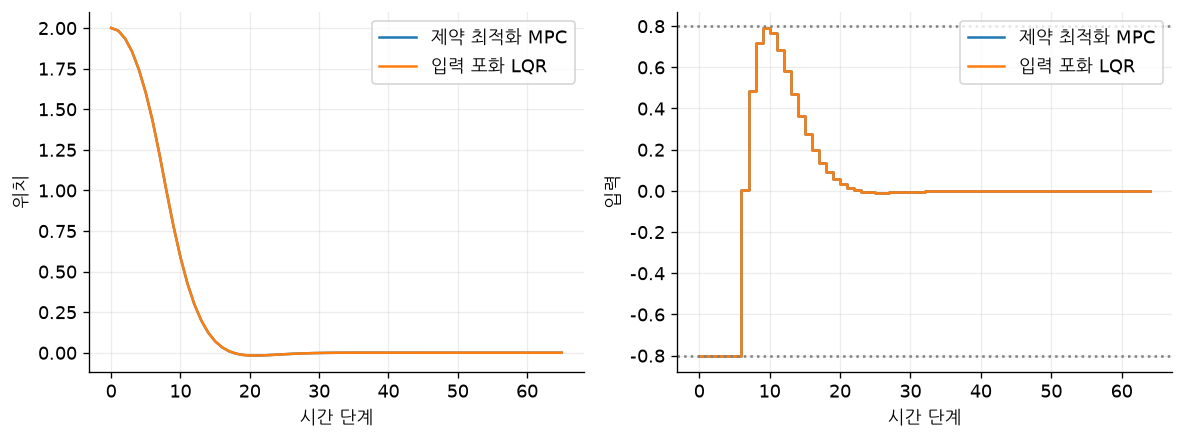

In [10]:
def demo_constrained_mpc():
    A = np.array([[1.0, 0.2], [0.0, 1.0]])
    B = np.array([[0.02], [0.2]])
    Q = np.diag([4.0, 1.0])
    R = np.array([[0.5]])
    P = solve_discrete_are(A, B, Q, R)
    K = -np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    N, limit = 15, 0.8
    x = cp.Variable((2, N + 1))
    u = cp.Variable((1, N))
    init = cp.Parameter(2)
    cons = [x[:, 0] == init]
    cost = 0.5 * cp.quad_form(x[:, N], P)
    for k in range(N):
        cost += 0.5 * (cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R))
        cons += [x[:, k + 1] == A @ x[:, k] + B @ u[:, k], cp.abs(u[:, k]) <= limit]
    problem = cp.Problem(cp.Minimize(cost), cons)

    def mpc(state, k):
        init.value = state
        checked_solve(problem)
        return u.value[:, 0].copy()

    xm, um = simulate_linear(A, B, mpc, [2.0, 0.0], 65)
    xl, ul = simulate_linear(
        A, B, lambda x, k: np.clip(K @ x, -limit, limit), [2.0, 0.0], 65
    )
    violation = max(0.0, float(np.max(np.abs(um)) - limit))
    assert violation < 1e-5 and np.linalg.norm(xm[-1]) < 0.02
    CHECKS["MPC input constraint violation"] = violation
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for label, xs, us in [("제약 최적화 MPC", xm, um), ("입력 포화 LQR", xl, ul)]:
        axes[0].plot(xs[:, 0], label=label)
        axes[1].step(np.arange(len(us)), us[:, 0], label=label)
    axes[0].set(xlabel="시간 단계", ylabel="위치")
    axes[1].set(xlabel="시간 단계", ylabel="입력")
    axes[1].axhline(limit, color="gray", ls=":")
    axes[1].axhline(-limit, color="gray", ls=":")
    for ax in axes:
        ax.legend()
    finish_figure("constrained_mpc")


demo_constrained_mpc()


**보충 실습 — 왜 첫 입력만 쓰고 다시 푸는가?**

같은 유한 구간 문제로 계산한 열린 고리 입력 열과 매 시점 재계산한 입력을 비교합니다. 모델은 $x^+=1.05x+u$, $N=12$, $Q=1,R=0.2$입니다. 실제 시스템에만 8번째 전이 직후 상태 충격 +1을 넣습니다. 제어기는 충격을 미리 알지 못하며 다음 측정부터 반영합니다. DARE 종단 비용을 써서 외란이 없을 때 두 방식이 같은 궤적을 만드는지 먼저 검사합니다.

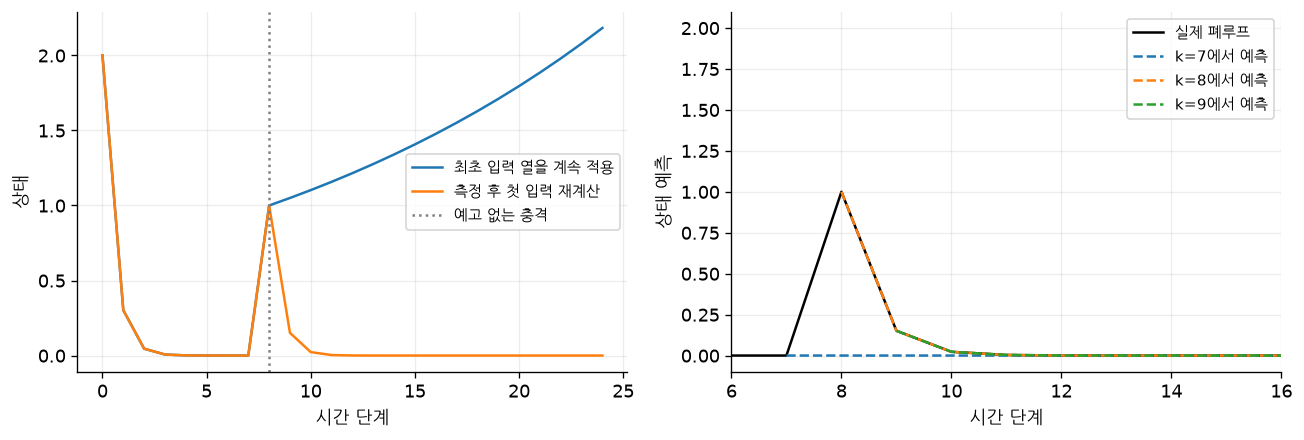

In [11]:
def demo_replanning():
    A = np.array([[1.05]])
    B = np.array([[1.0]])
    Q = np.eye(1)
    R = np.array([[0.2]])
    P = solve_discrete_are(A, B, Q, R)
    N = 12
    T = 24
    _, Ks = riccati(A, B, Q, R, P, N)
    K = Ks[0]
    baseline, planned = simulate_linear(A, B, lambda x, k: K @ x, [2.0], T)
    # 종단 DARE 해에서는 모든 유한 구간 이득이 동일하다.
    assert max(np.max(np.abs(k - K)) for k in Ks) < 1e-12
    xo = np.zeros(T + 1)
    xc = np.zeros(T + 1)
    xo[0] = xc[0] = 2.0
    predictions = []
    for k in range(T):
        if k in [7, 8, 9]:
            pred, _ = simulate_linear(A, B, lambda x, j: Ks[j] @ x, [xc[k]], N)
            predictions.append((k, pred[:, 0]))
        impulse = 1.0 if k == 7 else 0.0
        xo[k + 1] = 1.05 * xo[k] + planned[k, 0] + impulse
        xc[k + 1] = 1.05 * xc[k] + float((K @ np.array([xc[k]]))[0]) + impulse
    assert np.max(np.abs(xc[:8] - baseline[:8, 0])) < 1e-12
    assert abs(xc[-1]) < 1e-8 and xo[-1] > 1
    CHECKS["replanning final error"] = float(abs(xc[-1]))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(xo, label="최초 입력 열을 계속 적용")
    axes[0].plot(xc, label="측정 후 첫 입력 재계산")
    axes[0].axvline(8, color="gray", ls=":", label="예고 없는 충격")
    axes[0].set(xlabel="시간 단계", ylabel="상태")
    axes[0].legend(fontsize=9)
    axes[1].plot(xc, color="black", label="실제 폐루프")
    for k, pred in predictions:
        axes[1].plot(np.arange(k, k + N + 1), pred, "--", label=f"k={k}에서 예측")
    axes[1].set(xlim=(6, 16), xlabel="시간 단계", ylabel="상태 예측")
    axes[1].legend(fontsize=9)
    finish_figure("replanning")
    return {"open_loop": xo, "closed_loop": xc}


replanning_result = demo_replanning()


## 1.4 Introductory State Estimation — 상태 추정 입문

**교재 p.26–46**

상태를 직접 측정할 수 없거나 센서에 잡음이 있으면 모델 예측과 관측을 결합합니다. $\hat{x}_{k|k-1}$는 현재 측정 전 예측, $\hat{x}_{k|k}$는 현재 측정까지 사용한 추정입니다. 이 두 시점을 구분해야 필터의 구현과 성능 비교가 일관됩니다.

### 1.4.1 Linear Systems and Normal Distributions — 선형 시스템과 정규분포

**교재 p.27–29**

Gaussian 상태에 선형 변환을 적용하면 결과도 Gaussian입니다. 독립인 과정 잡음은 예측 공분산에 더해집니다. 평균뿐 아니라 공분산을 전파해야 모델 예측을 얼마나 신뢰할지 결정할 수 있습니다.

$$
\hat{x}_{k+1|k}=A\hat{x}_{k|k}+Bu_k,\qquad P_{k+1|k}=AP_{k|k}A^T+W
$$

**보충 실습 — 공분산의 모양과 측정에 의한 축소**

$x\sim\mathcal N(0,P)$, $P=\begin{bmatrix}1&0.7\\0.7&1\end{bmatrix}$, $y=[1\ 0]x+v$, $v\sim\mathcal N(0,0.2)$를 사용합니다. 첫 성분만 측정해도 두 성분이 상관되어 있으면 둘째 성분의 불확실성도 줄어듭니다. 오른쪽은 $y=1$로 조건화한 분포입니다. 타원은 $ (x-\mu)^TP^{-1}(x-\mu)=4$인 **Mahalanobis 반지름 2** 등고선으로, 2차원 포함 확률은 약 86.5%입니다. 1차원 ±2 표준편차의 약 95%와 구분합니다.

표본 그림은 분포의 시각화이며, 필터의 정확도 보장은 선형·Gaussian·모델 가정에서 나옵니다. 표본 공분산은 수치 근사로만 비교합니다.

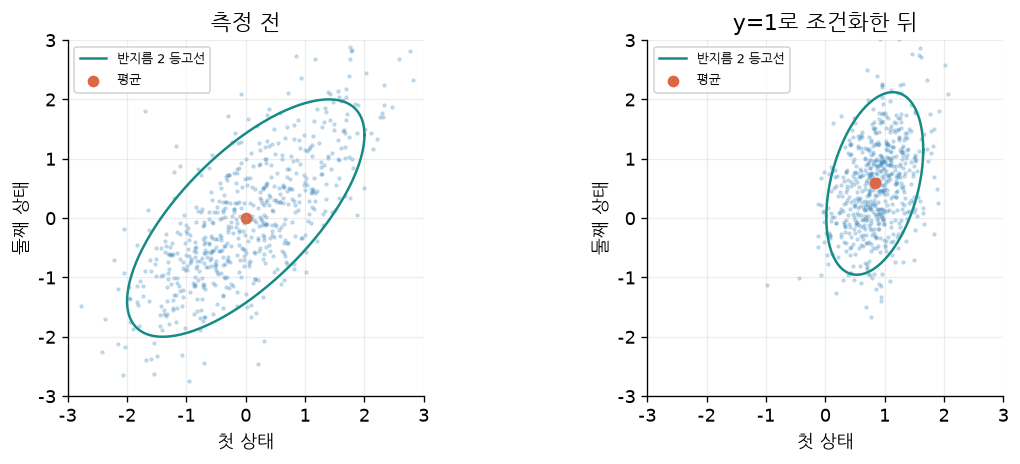

In [12]:
def demo_gaussian_geometry():
    rng = np.random.default_rng(17)
    P = np.array([[1.0, 0.7], [0.7, 1.0]])
    C = np.array([[1.0, 0.0]])
    V = np.array([[0.2]])
    L = np.linalg.solve(C @ P @ C.T + V, C @ P).T
    mean = L[:, 0]
    ILC = np.eye(2) - L @ C
    post = ILC @ P @ ILC.T + L @ V @ L.T
    assert np.linalg.eigvalsh(P - post).min() > -1e-12
    samples = rng.multivariate_normal(np.zeros(2), P, 30000)
    covariance_error = np.max(np.abs(np.cov(samples.T) - P))
    assert covariance_error < 0.04
    CHECKS["Gaussian sample covariance error"] = float(covariance_error)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = 2 * np.vstack([np.cos(theta), np.sin(theta)])
    for ax, title, mu, cov in [
        (axes[0], "측정 전", np.zeros(2), P),
        (axes[1], "y=1로 조건화한 뒤", mean, post),
    ]:
        cloud = rng.multivariate_normal(mu, cov, 600)
        ellipse = mu[:, None] + np.linalg.cholesky(cov) @ circle
        ax.scatter(cloud[:, 0], cloud[:, 1], s=3, alpha=0.2)
        ax.plot(ellipse[0], ellipse[1], color="#168b86", label="반지름 2 등고선")
        ax.scatter(*mu, color="#dd6644", label="평균")
        ax.set(
            title=title, xlabel="첫 상태", ylabel="둘째 상태", xlim=(-3, 3), ylim=(-3, 3)
        )
        ax.set_aspect("equal")
        ax.legend(fontsize=8)
    finish_figure("gaussian_geometry")
    return {"prior_cov": P, "posterior_cov": post, "posterior_mean": mean}


gaussian_result = demo_gaussian_geometry()


### 1.4.2 Linear Optimal State Estimation — 선형 최적 상태 추정

**교재 p.29–33**

Kalman Filter는 예측과 관측의 불확실성을 비교해 잔차에 가중치를 부여합니다. 선형·Gaussian 및 올바른 모델 가정에서는 조건부 평균이 최소 평균제곱오차 추정입니다. 모델이 틀리거나 공분산이 잘못 지정되면 이 최적성 해석은 달라집니다.

$$
L_k=P^-_kC^T(CP^-_kC^T+V)^{-1},\quad\hat{x}_k=\hat{x}^-_k+L_k(y_k-C\hat{x}^-_k)
$$

**보충 실습 — 위치 센서로 위치와 속도 추정**

관측은 위치 한 개지만 시간에 따른 위치 변화를 통해 속도를 추정할 수 있습니다.
실제 궤적과 관측을 한 번 생성하고, 같은 데이터에 필터를 적용합니다.

위치 RMSE: 측정=0.3582, KF=0.1279


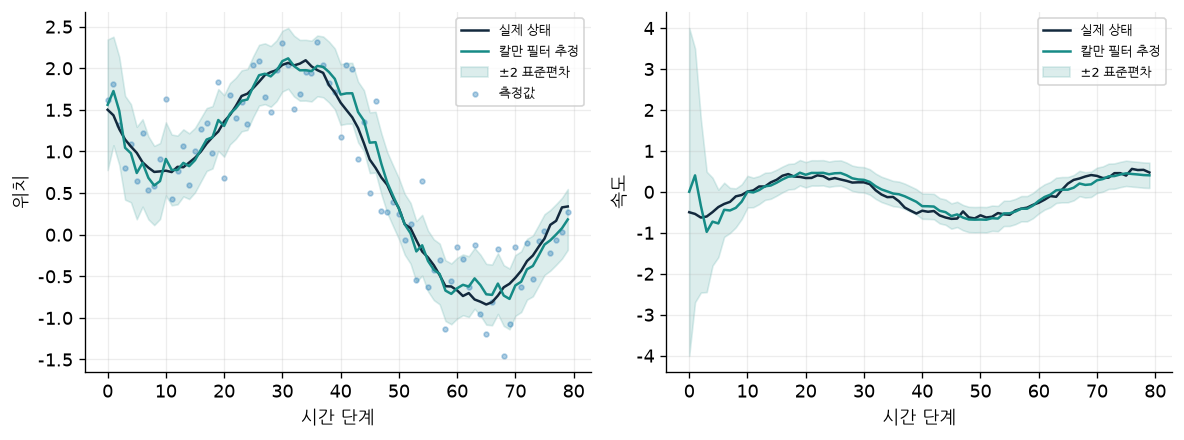

In [13]:
def demo_kalman():
    A, B, C, W, V, x, y, u = estimation_data()
    _, _, est, covs = kalman(A, B, C, W, V, y, u, np.zeros(2), 4 * np.eye(2))
    raw_rmse = np.sqrt(np.mean((y[:, 0] - x[:-1, 0]) ** 2))
    est_rmse = np.sqrt(np.mean((est[:, 0] - x[:-1, 0]) ** 2))
    assert est_rmse < raw_rmse
    assert np.linalg.eigvalsh(covs).min() > -1e-10
    CHECKS["KF position RMSE"] = float(est_rmse)
    print(f"위치 RMSE: 측정={raw_rmse:.4f}, KF={est_rmse:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for i in range(2):
        axes[i].plot(x[:-1, i], color="#13293d", label="실제 상태")
        axes[i].plot(est[:, i], color="#168b86", label="칼만 필터 추정")
        sigma = np.sqrt(covs[:, i, i])
        axes[i].fill_between(
            np.arange(80),
            est[:, i] - 2 * sigma,
            est[:, i] + 2 * sigma,
            alpha=0.15,
            color="#168b86",
            label="±2 표준편차",
        )
        axes[i].set(xlabel="시간 단계", ylabel=["위치", "속도"][i])
    axes[0].scatter(np.arange(80), y[:, 0], s=8, alpha=0.35, label="측정값")
    for ax in axes:
        ax.legend(fontsize=8)
    finish_figure("kalman_filter")


demo_kalman()


**해석:** 위치 오차뿐 아니라 직접 측정하지 않은 속도의 추정도 확인합니다.

### 1.4.3 Least Squares Estimation — 최소제곱 추정

**교재 p.33–39**

선형 Gaussian 추정은 초기상태 prior, 과정 잔차, 측정 잔차의 가중 제곱합을 최소화하는 문제로도 쓸 수 있습니다. 가중치는 공분산의 역행렬입니다. 같은 prior와 같은 데이터를 사용하면 배치 최적화의 마지막 상태 추정은 Kalman Filter의 현재 상태 추정과 일치합니다.

$$
\min\ \frac12\|x_0-\bar{x}_0\|^2_{P_0^{-1}}+\frac12\sum_{j=0}^{T-1}\|x_{j+1}-Ax_j-Bu_j\|^2_{W^{-1}}+\frac12\sum_{j=0}^{T}\|y_j-Cx_j\|^2_{V^{-1}}
$$

LS-KF 종점 차이: 1.44e-15; LS-QP 전체 차이: 2.00e-15


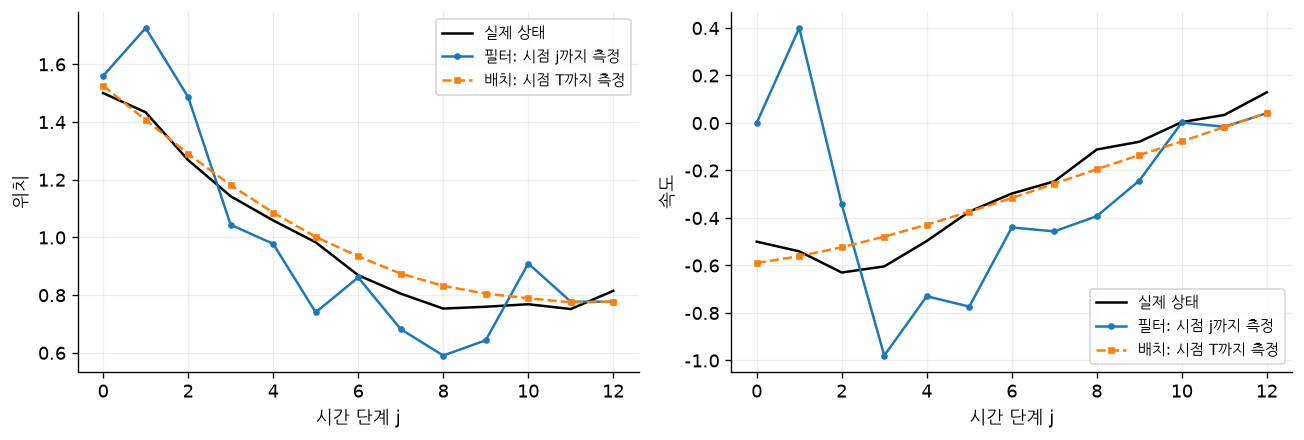

In [14]:
def demo_batch_ls():
    A, B, C, W, V, x, y, u = estimation_data()
    T = 12
    _, _, est, _ = kalman(A, B, C, W, V, y[: T + 1], u[:T], np.zeros(2), 4 * np.eye(2))
    smooth, residual = linear_window_ls(
        A, B, C, W, V, y[: T + 1], u[:T], (np.zeros(2), 4 * np.eye(2))
    )
    err = np.max(np.abs(smooth[-1] - est[-1]))
    assert err < 1e-9
    # 독립적인 CVXPY 표현과도 전체 상태 열을 대조한다. 역행렬은 만들지 않는다.
    z = cp.Variable((T + 1, 2))
    Lw = np.linalg.cholesky(W)
    Lv = np.linalg.cholesky(V)
    Hw = solve_triangular(Lw, np.eye(2), lower=True)
    Hv = solve_triangular(Lv, np.eye(1), lower=True)
    cost = cp.sum_squares(z[0] / 2)
    for j in range(T + 1):
        cost += cp.sum_squares(Hv @ (y[j] - C @ z[j]))
        if j < T:
            cost += cp.sum_squares(Hw @ (z[j + 1] - A @ z[j] - B @ u[j]))
    checked_solve(cp.Problem(cp.Minimize(0.5 * cost)))
    qp_err = np.max(np.abs(z.value - smooth))
    assert qp_err < 1e-8
    CHECKS["batch LS vs KF endpoint difference"] = float(err)
    CHECKS["whitened LS vs QP trajectory error"] = float(qp_err)
    print(f"LS-KF 종점 차이: {err:.2e}; LS-QP 전체 차이: {qp_err:.2e}")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for i, ax in enumerate(axes):
        ax.plot(x[: T + 1, i], color="black", label="실제 상태")
        ax.plot(est[:, i], "o-", ms=3, label="필터: 시점 j까지 측정")
        ax.plot(smooth[:, i], "s--", ms=3, label="배치: 시점 T까지 측정")
        ax.set(xlabel="시간 단계 j", ylabel=["위치", "속도"][i])
        ax.legend(fontsize=9)
    finish_figure("batch_smoothing")
    return {"filtered": est, "smoothed": smooth, "optimality_residual": residual}


batch_result = demo_batch_ls()


**해석:** 두 곡선의 **마지막 상태**는 일치하지만 앞부분은 다릅니다. 배치 문제는 나중 측정까지 사용해 과거 상태를 수정하는 평활화(smoothing)입니다. 따라서 앞부분의 배치 추정을 같은 시점의 실시간 필터 결과라고 부르면 안 됩니다. 특정 잡음 실현에서 평활화의 모든 시점 오차가 반드시 작아지는 것은 아닙니다.

### 1.4.4 Moving Horizon Estimation — 이동 구간 추정

**교재 p.39–41**

MHE는 최근 구간의 상태만 최적화하고, 구간 이전의 정보를 arrival cost로 요약합니다. 구간 시작이 $s$이면 prior는 $\hat{x}_{s|s-1},P_{s|s-1}$입니다. 최신 시점의 추정값을 시작 시점 prior로 넣으면 시간 인덱스가 맞지 않습니다.

선형 Gaussian·무제약 문제에서 정확한 arrival cost를 사용하면 MHE의 마지막 추정이 KF와 같습니다. 제약이나 근사 arrival cost를 쓰면 결과가 달라질 수 있습니다.

**보충 실습 — 정확한 도착 비용과 도착 비용 0 비교**

교재는 먼저 도착 비용을 0으로 두는 단순화를 설명하고, 버린 과거의 영향을 어떻게 요약할지 논의합니다. 여기서는 구간 시작 $s$의 측정 전 KF prior를 **정확한 도착 비용의 기준값**으로 사용합니다. 실제 MHE가 매번 KF를 실행해야 한다는 뜻은 아닙니다.

`window`는 **측정 개수**입니다. 측정 8개에는 상태 8개, 전이 7개가 들어갑니다. 도착 비용에는 $y_s$를 넣지 않고 구간 목적함수에서 한 번만 넣습니다. 비용 0인 경우도 초기 전체 구간에서는 같은 초기 prior를 쓰고, 구간이 이동한 뒤에만 prior를 버립니다. 관측가능성이 필요하므로 이 비교의 최소 구간은 2입니다.

구간 길이별 RMS는 모두 같은 시점 **k=16–79**에서 평가합니다. 길이에 따라 평가 구간까지 바뀌는 혼동을 피합니다.

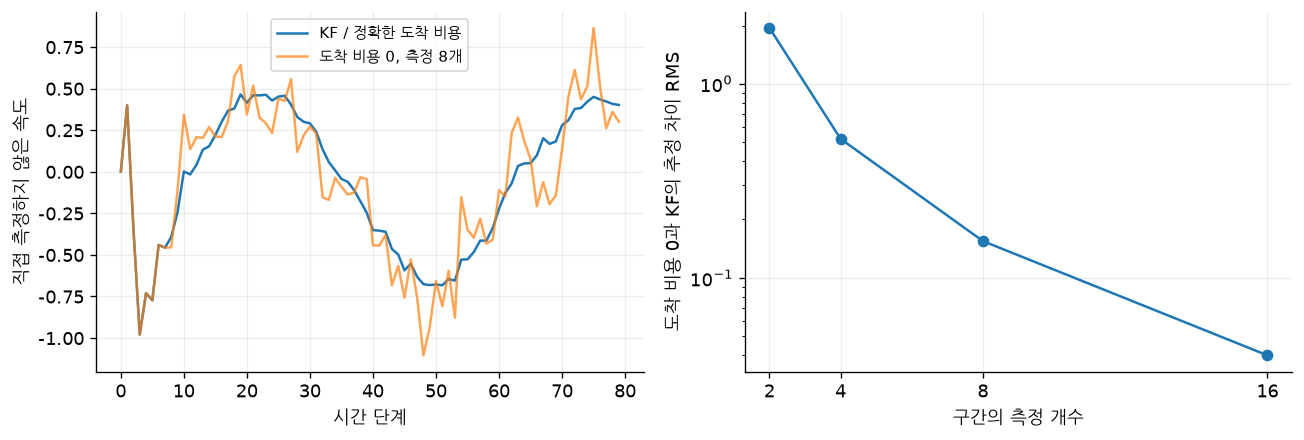

정확한 도착 비용 MHE-KF 최대 차이: 4.44e-15


In [15]:
def demo_mhe(window=8):
    if not isinstance(window, (int, np.integer)) or window < 2:
        raise ValueError("이 비교의 window는 2 이상의 정수여야 합니다.")
    A, B, C, W, V, x, y, u = estimation_data()
    pm, pP, est, _ = kalman(A, B, C, W, V, y, u, np.zeros(2), 4 * np.eye(2))
    exact = []
    dropped = []
    for k in range(len(y)):
        s = max(0, k - window + 1)
        ze, _ = linear_window_ls(A, B, C, W, V, y[s : k + 1], u[s:k], (pm[s], pP[s]))
        zd, _ = linear_window_ls(
            A, B, C, W, V, y[s : k + 1], u[s:k], (pm[s], pP[s]) if s == 0 else None
        )
        exact.append(ze[-1])
        dropped.append(zd[-1])
    exact = np.array(exact)
    dropped = np.array(dropped)
    err = np.max(np.abs(exact - est))
    assert err < 1e-8
    CHECKS["MHE vs KF max difference"] = float(err)
    windows = [2, 4, 8, 16]
    rms = []
    for width in windows:
        delta = []
        for k in range(max(windows), len(y)):
            s = k - width + 1
            zz, _ = linear_window_ls(A, B, C, W, V, y[s : k + 1], u[s:k])
            delta.append(zz[-1] - est[k])
        rms.append(float(np.sqrt(np.mean(np.array(delta) ** 2))))
    assert rms[-1] < rms[0]  # 이 고정 데이터의 관찰. 일반적인 단조성 보장은 아님.
    CHECKS["zero arrival vs KF RMS by window"] = rms
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(est[:, 1], label="KF / 정확한 도착 비용")
    axes[0].plot(dropped[:, 1], alpha=0.7, label=f"도착 비용 0, 측정 {window}개")
    axes[0].set(xlabel="시간 단계", ylabel="직접 측정하지 않은 속도")
    axes[0].legend(fontsize=9)
    axes[1].semilogy(windows, rms, "o-")
    axes[1].set(
        xticks=windows, xlabel="구간의 측정 개수", ylabel="도착 비용 0과 KF의 추정 차이 RMS"
    )
    finish_figure("mhe_comparison")
    print(f"정확한 도착 비용 MHE-KF 최대 차이: {err:.2e}")
    return {"exact": exact, "zero_arrival": dropped, "window_rms": dict(zip(windows, rms))}


mhe_result = demo_mhe()


### 1.4.5 Observability — 관측가능성

**교재 p.41–43**

관측가능성은 유한 길이의 출력 기록으로 초기상태를 유일하게 구별할 수 있는 성질입니다. 검출 가능성은 관측 불가능한 모드가 안정하면 만족하는 더 약한 조건입니다. 위치만 관측해도 동역학에 속도가 연결되어 있으면 속도를 추정할 수 있습니다.

$$
\mathcal{O}=\begin{bmatrix}C\\CA\\\vdots\\CA^{n-1}\end{bmatrix},\quad\operatorname{rank}\mathcal{O}=n
$$

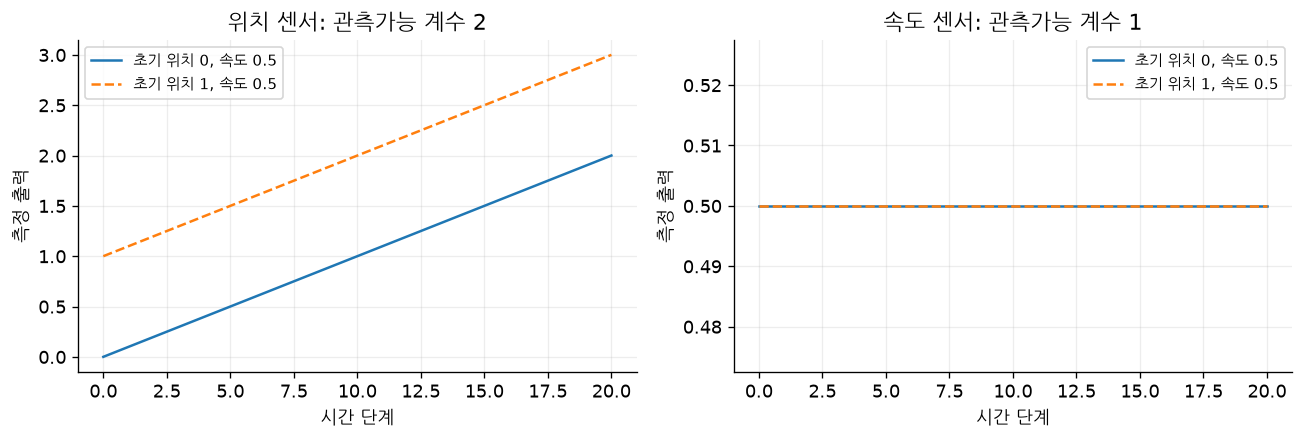

[2, 1]

In [16]:
def demo_observability():
    A = np.array([[1.0, 0.2], [0.0, 1.0]])
    B = np.zeros((2, 1))
    # 같은 속도, 다른 위치의 두 초기상태를 센서가 구별하는가?
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ranks = []
    for ax, C, label in [
        (axes[0], np.array([[1.0, 0.0]]), "위치 센서"),
        (axes[1], np.array([[0.0, 1.0]]), "속도 센서"),
    ]:
        rank = int(np.linalg.matrix_rank(np.vstack([C, C @ A])))
        ranks.append(rank)
        for x0, style in [([0.0, 0.5], "-"), ([1.0, 0.5], "--")]:
            xs, _ = simulate_linear(A, B, lambda x, k: [0.0], x0, 20)
            ax.plot((xs @ C.T)[:, 0], style, label=f"초기 위치 {x0[0]:g}, 속도 0.5")
        ax.set(
            title=f"{label}: 관측가능 계수 {rank}", xlabel="시간 단계", ylabel="측정 출력"
        )
        ax.legend(fontsize=9)
    assert ranks == [2, 1]
    CHECKS["observability ranks"] = ranks
    finish_figure("observability")
    return ranks


demo_observability()


**해석:** 위치 센서는 두 초기상태를 즉시 구별하며, 시간에 따른 위치 변화로 속도도 알아냅니다. 속도 센서만 있으면 일정한 위치 차이는 출력에 전혀 나타나지 않습니다. 오른쪽 두 선은 겹칩니다. 여기서 관측 불가능한 위치 모드의 고유값은 1이므로 검출 가능성도 만족하지 않습니다.

### 1.4.6 Convergence of the State Estimator — 상태 추정기의 수렴

**교재 p.43–46**

잡음이 없는 경우에는 관측가능성 등 조건 아래 초기 추정 오차가 사라지는지를 봅니다. 잡음이 계속 들어오는 경우에는 개별 추정 오차가 항상 0으로 가는 것이 아니라 오차의 통계적 크기와 공분산을 평가합니다.

최소 비용의 수렴만으로 상태 추정 오차의 수렴을 주장할 수는 없습니다. 관측으로 구별되지 않는 불안정 모드는 별도로 확인해야 합니다.

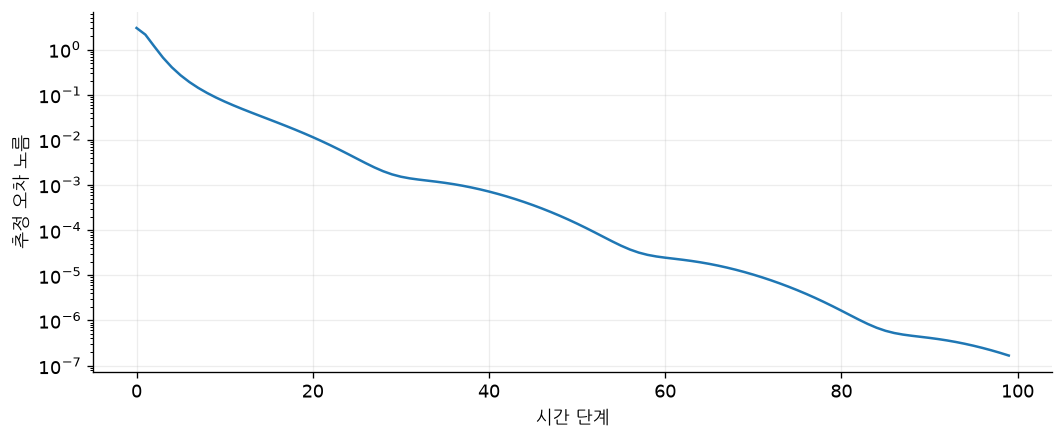

In [17]:
def demo_estimator_convergence():
    A, B, C, W, V, _, _, _ = estimation_data()
    u = np.zeros((100, 1))
    x = np.zeros((100, 2))
    x[0] = [2.0, -1.0]
    for k in range(99):
        x[k + 1] = A @ x[k]
    y = x @ C.T
    _, _, est, _ = kalman(A, B, C, W, V, y, u, np.array([-2.0, 2.0]), 4 * np.eye(2))
    err = np.linalg.norm(est - x, axis=1)
    assert err[-1] < 1e-5
    CHECKS["noise-free final estimation error"] = float(err[-1])
    plt.figure()
    plt.semilogy(np.maximum(err, 1e-16))
    plt.xlabel("시간 단계")
    plt.ylabel("추정 오차 노름")
    finish_figure("estimator_convergence")


demo_estimator_convergence()


**수렴의 의미를 구분하기:** 위 실험의 실제 시스템에는 과정·측정 잡음이 없습니다. 필터의 양의 $W,V$는 이득을 설계하기 위한 공분산 설정입니다. 따라서 그래프는 초기 추정 오차가 사라지는 모습을 보여 줍니다. 실제로 잡음이 계속 들어오면 순간 오차가 0으로 수렴한다고 말할 수 없고, 오차 공분산의 유계성·정상값을 살펴야 합니다.

## 1.5 Tracking, Disturbances, and Zero Offset — 추종·외란·정상상태 오차 제거

**교재 p.46–59**

원점 조절기를 목표값 추종에 사용하려면 먼저 목표 출력과 일치하는 정상상태를 구합니다. 실제 공정에 일정 외란이 있으면 이 정상상태 계산에도 추정한 외란이 반영되어야 합니다.

전체 구조는 상태·외란 추정기, 정상상태 목표 계산기, 편차 조절기로 나뉩니다.

### 1.5.1 Tracking — 목표값 추종

**교재 p.46–49**

제어 출력 $r=Hy$에 대해 정상상태 $(x_s,u_s)$가 모델과 목표 $r$을 동시에 만족하도록 계산합니다. 그다음 편차 $\tilde{x}=x-x_s$, $\tilde{u}=u-u_s$를 원점으로 조절합니다. 제약이 있으면 목표의 실현 가능성과 이동한 제약 범위도 확인해야 합니다.

$$
\begin{bmatrix}I-A&-B\\HC&0\end{bmatrix}\begin{bmatrix}x_s\\u_s\end{bmatrix}=\begin{bmatrix}0\\r\end{bmatrix},\qquad u=u_s+K(x-x_s)
$$

**측정 출력 y와 제어할 출력 r의 구분 (교재 pp.46–49)**

측정 출력이 $y=Cx\in\mathbb R^p$이고 제어할 출력이 $r=Hy\in\mathbb R^{n_c}$이면 목표는 $Cx_s=r$가 아니라 $HCx_s=r$입니다. 정상상태 방정식 $(I-A)x_s-Bu_s=0$과 함께 풉니다. 필요한 차원 조건 $n_c\le m,p$만으로는 충분하지 않고, 계수·목표 제약의 실행 가능성도 확인해야 합니다. 목표 계산에는 입력·상태 선호값에 대한 이차 비용과 운전 제약을 넣을 수 있습니다.

**보충 실습:** $A=\mathrm{diag}(0.8,0.6)$, $B=[0.2,0.1]^T$, $C=I$이면 정상 출력은 $[u_s,0.25u_s]^T$ 위에만 놓입니다. 측정값이 두 개여도 입력 한 개로 임의의 두 목표를 정할 수는 없습니다. $H=[1,0]$으로 첫 출력만 제어하면 목표를 선택할 수 있지만, $|u_s|\le0.6$에서는 목표 1을 정확히 맞출 수 없습니다. 아래 완화는 목표 오차를 허용하는 별도의 설계 선택입니다.

편차 입력 $u_e=u-u_s$의 제약도 옮겨야 합니다. $u\in[-0.6,0.6]$이면 $u_e\in[-0.6-u_s,0.6-u_s]$입니다. 원점 주변의 대칭 한계를 그대로 쓰면 실제 입력 제약을 위반할 수 있습니다.

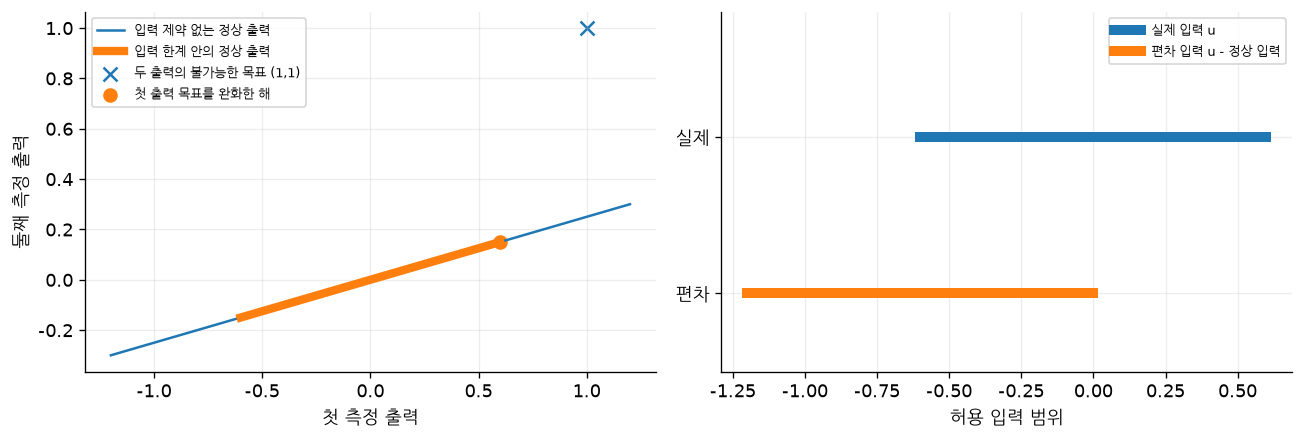

In [18]:
def demo_target_geometry():
    A = np.diag([0.8, 0.6])
    B = np.array([[0.2], [0.1]])
    C = np.eye(2)
    H = np.array([[1.0, 0.0]])
    target = 1.0
    limit = 0.6
    xs = cp.Variable(2)
    us = cp.Variable(1)
    cons = [(np.eye(2) - A) @ xs == B @ us, cp.abs(us) <= limit]
    problem = cp.Problem(cp.Minimize(cp.sum_squares(H @ C @ xs - target)), cons)
    info = checked_solve(problem)
    assert abs(us.value[0] - 0.6) < 1e-6 and abs(xs.value[0] - 0.6) < 1e-6
    CHECKS["limited target unavoidable error"] = float(target - xs.value[0])
    sweep = np.linspace(-1.2, 1.2, 100)
    eq = np.linalg.solve(np.eye(2) - A, B)[:, 0]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(sweep * eq[0], sweep * eq[1], label="입력 제약 없는 정상 출력")
    feasible = np.linspace(-limit, limit, 100)
    axes[0].plot(feasible, feasible * 0.25, lw=5, label="입력 한계 안의 정상 출력")
    axes[0].scatter([1], [1], marker="x", s=70, label="두 출력의 불가능한 목표 (1,1)")
    axes[0].scatter(*xs.value, s=60, label="첫 출력 목표를 완화한 해")
    axes[0].set(xlabel="첫 측정 출력", ylabel="둘째 측정 출력")
    axes[0].legend(fontsize=8)
    shifted = np.array([-limit, limit]) - us.value[0]
    axes[1].plot([-limit, limit], [1, 1], lw=6, label="실제 입력 u")
    axes[1].plot(shifted, [0, 0], lw=6, label="편차 입력 u - 정상 입력")
    axes[1].set(
        yticks=[0, 1],
        yticklabels=["편차", "실제"],
        xlabel="허용 입력 범위",
        ylim=(-0.5, 1.8),
    )
    axes[1].legend(fontsize=8)
    finish_figure("target_geometry")
    return {
        "state_target": xs.value,
        "input_target": us.value,
        "shifted_bounds": shifted,
        **info,
    }


target_result = demo_target_geometry()


### 1.5.2 Disturbances and Zero Offset — 외란과 정상상태 오차 제거

**교재 p.49–59**

일정 외란을 표현하는 적분 상태 $d^+=d$를 모델에 추가하고 관측으로 추정합니다. 확장 모델은 검출 가능해야 하며, 추정한 외란을 정상상태 목표 계산에 넣습니다.

교재의 논점은 안정화되어 정상상태에 도달하고 관련 가정이 충족될 때의 zero offset입니다. 적분 상태를 추가했다는 사실만으로 제약하 안정성이나 임의 외란 제거가 보장되지는 않습니다.

$$
\begin{bmatrix}x\\d\end{bmatrix}^{+}=\begin{bmatrix}A&B_d\\0&I\end{bmatrix}\begin{bmatrix}x\\d\end{bmatrix}+\begin{bmatrix}B\\0\end{bmatrix}u,\qquad y=Cx+C_dd
$$

**보충 실습 — 입력에 일정 외란이 들어오는 스칼라 공정**

실제 공정은 $x^+=0.9x+0.2u+d$, $y=x$이고 $k=35$부터 $d=0.08$입니다.
측정 잡음은 꺼 두어 정상상태 오차를 분명하게 비교합니다. 기본 제어기는 명목 목표를 사용하며,
확장 제어기는 상태와 외란을 추정하고 $(1-a)x_s-bu_s=\hat d$를 풉니다.
입력 제약이 없는 교육용 실습입니다. 교재 Example 1.11의 화학반응기 재현은 아닙니다.

마지막 20점 평균 오차: 명목=0.244416, 외란 추정=4.44e-16


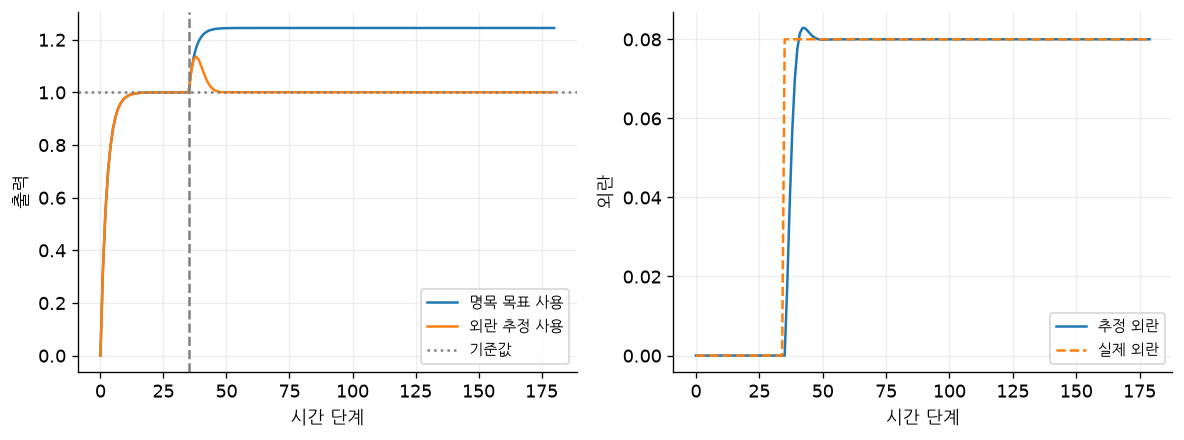

In [19]:
def demo_tracking():
    a, b = 0.9, 0.2
    steps = 180
    r = 1.0
    A = np.array([[a]])
    B = np.array([[b]])
    Q = np.array([[1.0]])
    R = np.array([[0.3]])
    P = solve_discrete_are(A, B, Q, R)
    K = float((-np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)).item())
    Aa = np.array([[a, 1.0], [0.0, 1.0]])
    Ba = np.array([b, 0.0])
    Ca = np.array([[1.0, 0.0]])
    assert np.linalg.matrix_rank(np.vstack([Ca, Ca @ Aa])) == 2
    W = np.diag([1e-5, 1e-4])
    V = np.array([[1e-3]])
    prior = np.zeros(2)
    cov = np.eye(2)
    xb = np.zeros(steps + 1)
    xo = np.zeros(steps + 1)
    dh = []
    uo = []
    for k in range(steps):
        disturbance = 0.08 if k >= 35 else 0.0
        ub = (1 - a) * r / b + K * (xb[k] - r)
        xb[k + 1] = a * xb[k] + b * ub + disturbance
        L = np.linalg.solve(Ca @ cov @ Ca.T + V, Ca @ cov).T
        post = prior + L.flatten() * (xo[k] - float((Ca @ prior).item()))
        IL = np.eye(2) - L @ Ca
        post_cov = IL @ cov @ IL.T + L @ V @ L.T
        xs = r
        us = ((1 - a) * xs - post[1]) / b
        u = us + K * (post[0] - xs)
        xo[k + 1] = a * xo[k] + b * u + disturbance
        prior = Aa @ post + Ba * u
        cov = Aa @ post_cov @ Aa.T + W
        dh.append(post[1])
        uo.append(u)
    base_err = float(np.mean(xb[-20:] - r))
    offset_err = float(np.mean(xo[-20:] - r))
    assert abs(offset_err) < 1e-5 and abs(base_err) > 0.01
    CHECKS["offset-free steady error"] = offset_err
    CHECKS["nominal steady error"] = base_err
    print(f"마지막 20점 평균 오차: 명목={base_err:.6f}, 외란 추정={offset_err:.2e}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(xb, label="명목 목표 사용")
    axes[0].plot(xo, label="외란 추정 사용")
    axes[0].axhline(r, color="gray", ls=":", label="기준값")
    axes[0].axvline(35, color="gray", ls="--")
    axes[0].set(xlabel="시간 단계", ylabel="출력")
    axes[1].plot(dh, label="추정 외란")
    axes[1].plot(np.where(np.arange(steps) >= 35, 0.08, 0), "--", label="실제 외란")
    axes[1].set(xlabel="시간 단계", ylabel="외란")
    for ax in axes:
        ax.legend(fontsize=9)
    finish_figure("offset_free_tracking")


demo_tracking()


**결과 해석과 추가 실험**

기본 제어기에는 외란을 보상할 정상상태 입력이 없어 오차가 남습니다. 확장 제어기는 외란 추정에 따라 정상상태 입력을 조정합니다.
외란 크기, 센서 잡음, 입력 제한을 순서대로 추가해 보세요. 입력 제한으로 목표가 불가능해지면 zero offset도 기대할 수 없습니다.

**원본 Example 1.11 — 반응기 외란 모델의 계수 검사 (교재 pp.53–59)**

원본의 반올림된 이산 선형 행렬을 그대로 사용합니다. 상태는 농도·온도·액위의 운전점 편차, 입력은 냉각수 온도·유출 유량 편차입니다. 세 상태를 측정하지만 농도·액위 두 개만 제어합니다: $C=I_3$, $H=\begin{bmatrix}1&0&0\\0&0&1\end{bmatrix}$.

상수 외란 모델 $d^+=d$, $x^+=Ax+Bu+B_dd$, $y=Cx+C_dd$의 확장 계수를 검사합니다.
$$\operatorname{rank}\begin{bmatrix}I-A&-B_d\\C&C_d\end{bmatrix}=n+n_d.$$
이는 $(A,C)$가 검출 가능할 때 확장 모델의 검출 가능성 조건입니다(보조정리 1.8). 정규행렬의 특이값은 좌표 단위에 의존하므로 그림은 계수 부족을 찾는 용도로만 읽습니다.

- (a) 농도·액위에 출력 외란 2개: 확장 모델은 관측 가능하지만 $n_d=2<p=3$이므로 일반적인 무오프셋 보장은 얻지 못합니다.
- (b) 측정 출력마다 독립 출력 외란 3개: 액위 적분 모드와 출력 외란을 구별하지 못하여 계수가 부족합니다.
- (c) 출력 외란 2개와 유출 입력 방향의 외란 1개: 계수 조건과 $n_d=p$를 만족합니다.

보조정리 1.10의 무오프셋 결론에는 실행 가능한 목표, 폐루프의 정상상태 도달, 정상상태에서 제약 비활성 등의 가정도 필요합니다. **외란 개수만 늘리면 된다는 뜻이 아닙니다.** 아래는 원본 선형 행렬의 구조 검사이며, 비선형 반응기의 Figures 1.8–1.11를 재현한 시뮬레이션은 아닙니다. 앞의 스칼라 추종은 별도 보충 예제입니다.

행렬은 **샘플링 간격 1분**, 농도 0.878 kmol/m³·온도 324.5 K·액위 0.659 m의 운전점 선형화입니다. (b)의 외란 열 순서도 원본과 같이 농도·액위·온도를 따릅니다.

(a) 출력 외란 2개: rank=5, 필요 계수=5, 외란 수=2, 측정 수=3
(b) 출력 외란 3개: rank=5, 필요 계수=6, 외란 수=3, 측정 수=3
(c) 출력 2 + 입력 1: rank=6, 필요 계수=6, 외란 수=3, 측정 수=3


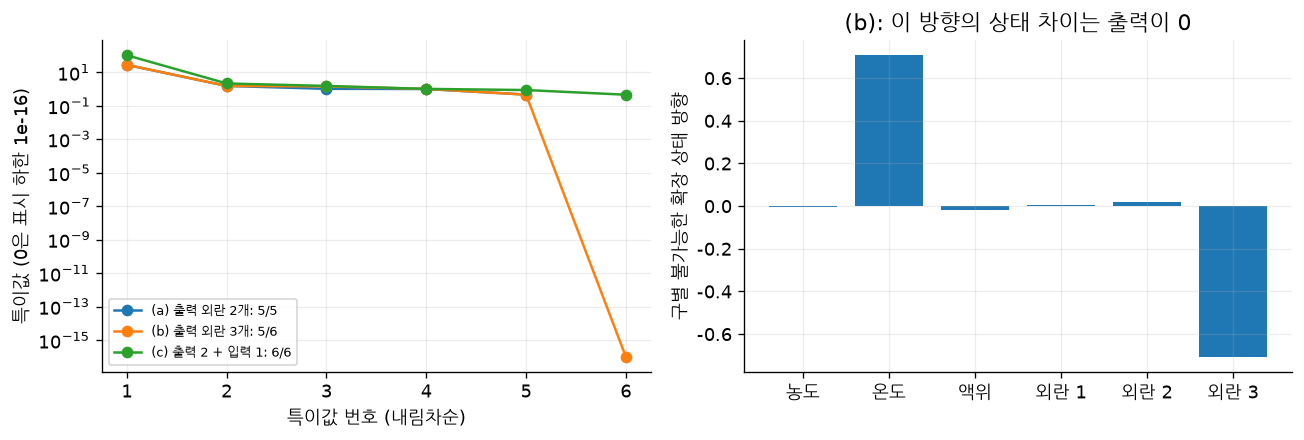

In [20]:
def demo_reactor_disturbance_rank():
    A = np.array([[0.2681, -0.00338, -0.00728], [9.703, 0.3279, -25.44], [0.0, 0.0, 1.0]])
    B = np.array([[-0.00537, 0.1655], [1.297, 97.91], [0.0, -6.637]])
    C = np.eye(3)
    H = np.array([[1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])
    Cd2 = np.array([[1.0, 0.0], [0.0, 0.0], [0.0, 1.0]])
    Bdc = np.zeros((3, 3))
    Bdc[:, 2] = B[:, 1]
    Cdc = np.column_stack([Cd2, np.zeros(3)])
    cases = [
        ("(a) 출력 외란 2개", np.zeros((3, 2)), Cd2),
        (
            "(b) 출력 외란 3개",
            np.zeros((3, 3)),
            np.array([[1.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, 1.0, 0.0]]),
        ),
        ("(c) 출력 2 + 입력 1", Bdc, Cdc),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ranks = []
    null_residual = None
    for label, Bd, Cd in cases:
        nd = Bd.shape[1]
        M = np.block([[np.eye(3) - A, -Bd], [C, Cd]])
        _, sigma, Vh = np.linalg.svd(M)
        rank = int(np.linalg.matrix_rank(M))
        ranks.append(rank)
        axes[0].semilogy(
            np.arange(1, len(sigma) + 1),
            np.maximum(sigma, 1e-16),
            "o-",
            label=f"{label}: {rank}/{3+nd}",
        )
        print(f"{label}: rank={rank}, 필요 계수={3+nd}, 외란 수={nd}, 측정 수={C.shape[0]}")
        if nd == 3 and rank < 6:
            null = Vh[-1]
            null_residual = np.linalg.norm(M @ null)
            assert null_residual < 1e-10
            Aa = np.block([[A, Bd], [np.zeros((nd, 3)), np.eye(nd)]])
            Ca = np.hstack([C, Cd])
            states = [null]
            for k in range(15):
                states.append(Aa @ states[-1])
            outputs = np.array(states) @ Ca.T
            assert np.max(np.abs(outputs)) < 1e-10
            axes[1].bar(np.arange(6), null)
    assert ranks == [5, 5, 6]
    CHECKS["reactor augmented ranks"] = ranks
    CHECKS["reactor unobservable mode residual"] = float(null_residual)
    axes[0].set(xlabel="특이값 번호 (내림차순)", ylabel="특이값 (0은 표시 하한 1e-16)")
    axes[0].legend(fontsize=8)
    axes[1].set(
        xticks=np.arange(6),
        xticklabels=["농도", "온도", "액위", "외란 1", "외란 2", "외란 3"],
        ylabel="구별 불가능한 확장 상태 방향",
        title="(b): 이 방향의 상태 차이는 출력이 0",
    )
    finish_figure("reactor_disturbance_rank")
    return {"ranks": ranks, "C": C, "H": H}


reactor_result = demo_reactor_disturbance_rank()


## 1.6 Exercises — 연습문제

**교재 p.60–88**

교재 연습문제 번호는 그대로 참조하고, 아래에는 이번 실습과 연결되는 선택 문제와 자체 점검 과제를 제공합니다. 모든 교재 문제의 풀이를 수록한 것은 아닙니다.

Exercise 1.5(pp.63): 연속시간 선형 모델의 이산화. Exercise 1.8(pp.64): 유한차분과 행렬 지수 근사. Exercise 1.22(pp.69): 정상상태 Riccati 방정식.

### 보충 연습 A — 이산화 오차
`demo_discretization(dt=...)`의 샘플링 간격을 바꾸세요. 비교하는 총 물리적 시간도 같게 맞추려면 무엇을 바꿔야 할까요?
Euler가 위치에 누락하는 한 단계 항을 구해 보세요.

### 보충 연습 B — LQ 안정성
§1.3.4 사례에서 $P_f=Q$ 대신 DARE 해를 사용하세요. 첫 피드백 이득이 예측 구간에 의존하는지 확인하고 이유를 설명하세요.

### 보충 연습 C — 관측가능성
위치 센서 대신 속도 센서만 사용하면 어떤 초기상태 정보를 잃는지 설명하세요. rank 계산과 출력 궤적을 함께 보세요.

### 보충 연습 D — MHE prior
정확한 arrival cost를 고정 prior로 바꿨을 때 KF와의 차이가 생기는 이유를 설명하세요. 비교 데이터와 오차를 평가하는 시점은 같게 유지하세요.

### 보충 연습 E — 실현 가능한 추종
목표 정상상태 입력이 허용 범위를 벗어나도록 입력 제약을 추가하세요. 목표값을 수정하는 방법과 단순 입력 clipping의 차이를 정리하세요.

<details><summary>힌트와 확인 기준</summary>

- A: ZOH의 위치 입력 항은 $\Delta^2u/2$입니다. 총 시간 고정 시 단계 수를 함께 조절합니다.
- B: DARE 해는 Riccati 재귀의 고정점이므로 무제약 LQ에서는 모든 단계에서 같은 이득을 얻습니다.
- C: 속도만 측정하면 초기 위치의 상수 차이가 출력에 나타나지 않습니다.
- D: arrival cost는 창 밖 정보의 요약입니다. 잘못된 시점이나 고정 prior는 다른 추정 문제를 만듭니다.
- E: 정상상태 방정식과 입력 범위를 동시에 만족하는지 먼저 확인하세요.

</details>

## 챕터 정리

| 질문 | 확인할 도구 |
|---|---|
| 미래를 어떻게 예측하는가? | 상태공간 모델·이산화 |
| 어떤 입력이 좋은가? | 비용함수·DP·Riccati·QP |
| 제어기가 안정한가? | 가정·폐루프 고유값·값 함수 감소 |
| 보이지 않는 상태를 어떻게 추정하는가? | 관측가능성·KF·최소제곱·MHE |
| 목표값을 어떻게 유지하는가? | 정상상태 목표·편차 제어·외란 추정 |

## 실행 검증 결과

아래 값은 위 실습을 모두 실행했을 때의 수치 검사 결과입니다. 고정된 기본 설정의 회귀 검사이며 일반적인 수학적 보장의 대체물은 아닙니다.

In [21]:
import json

print(json.dumps(CHECKS, ensure_ascii=False, indent=2))
print(f"총 {len(CHECKS)}개 수치 지표. 모든 수치 검사를 통과했습니다.")


{
  "initial plus forced response error": 5.551115123125783e-16,
  "PDE spatial error ratio min": 4.0001440152945635,
  "ZOH analytical match": 1.7763568394002505e-15,
  "soft constraint max residual": 7.548031311088721e-09,
  "Schur value error": 8.881784197001252e-16,
  "DP vs QP max input difference": 1.6930901125533637e-15,
  "finite horizon N5 rho": 1.3067250833951554,
  "finite horizon N7 rho": 0.9885689955062092,
  "controllability ranks": [
    2,
    1
  ],
  "MPC input constraint violation": 9.15092024378339e-09,
  "replanning final error": 7.47395199650363e-14,
  "Gaussian sample covariance error": 0.010406600695569646,
  "KF position RMSE": 0.12789854432049136,
  "batch LS vs KF endpoint difference": 1.4432899320127035e-15,
  "whitened LS vs QP trajectory error": 1.9984014443252818e-15,
  "MHE vs KF max difference": 4.440892098500626e-15,
  "zero arrival vs KF RMS by window": [
    1.9424053064438906,
    0.5207498814258347,
    0.1547440597717231,
    0.03985309102831043
 

## 참고 자료와 범위

- Rawlings, Mayne, Diehl (2017), *Model Predictive Control: Theory, Computation, and Design*, 2nd edition, 1st printing, Chapter 1.
- 교재의 식 번호를 재부여하지 않았습니다. 본문 수식은 설명을 위해 표기를 일부 단순화했습니다.
- 제어 입력 부호는 `u = Kx`; 상태 비용은 `Q,R`, 추정 잡음 공분산은 `W,V`로 구분합니다.
- pp.21–22의 LQ 불안정 사례를 제외한 실행 예제는 보충 실습입니다.
- §1.6은 선택 문제 안내와 보충 과제이며 교재 전체 연습문제 해설은 포함하지 않습니다.